###### **clone repo / config sys.path**

In [ ]:
!git clone https://github.com/Denisonya/algorithms-2s.git

import sys

# прописываем путь к директории
path_to_folder = '/content/algorithms-2s'

# добавляем этот путь в sys.path, чтобы Python мог искать там модули
if path_to_folder not in sys.path:
    sys.path.append(path_to_folder)

%cd algorithms-2s/lab2

###### **imports**

In [3]:
import importlib

# мои модули
import utils

# перезагружаем модуль
importlib.reload(utils)

from utils import time_and_memory_decorator

###### **title**

<h1></h1>

<div align="center">
  <h1><b>Министерство науки и высшего образования Российской Федерации</b></h1>

  <h1>ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
  </h1>

  <h1><b>НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО</b></h1>

  <h1>ITMO University</h1>

  <h1>ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ</h1>

  <br><br>

  <h3>Отчет по лабораторной работе №1</h3>
  <h3>по дисциплине «Алгоритмы и структуры данных»</h3>
  <h3>Тема: Двоичные деревья поиска</h3>
  <h3>Вариант 1</h3>
</div>

<br><br>

<div align="right">
  <h5><b>Выполнил:</b></h5>
  <h5>Баранов Д.С.</h5>
  <h5>К3140</h5>

  <br>

  <h5><b>Проверил:</b></h5>
  <h5>Царьков Г.И.</h5>
</div>

<br><br>

<div align="center">
  <h5>Санкт-Петербург</h5>
  <h5>2026 г.</h5>
</div>


<h1></h1>

<div align="center">
  <h1><b>Содержание отчета</b><h1>
</div>

| Раздел                                                        | Страница |
|:--------------------------------------------------------------|:--------:|
| **Задачи по варианту**                                        |    1     |
| Задача №1. Обход двоичного дерева [1 балла]                   |    1     |
| Задача №3. Простейшее BST [1 балла]                           |    2     |
| Задача №12. Проверка сбалансированности [2 балла]             |    3     |
| Задача №17. Множество с суммой [3 балла]                      |    4     |
| **Дополнительные задачи**                                     |    5     |
| Задача №18. Веревка [5 балла]                                 |    5     |
| Задача №4. Простейший неявный ключ [1 балла]                  |    6     |
| Задача №5. Простое двоичное дерево поиска [1 балла]           |    7     |
| Задача №6. Опознание двоичного дерева поиска [1.5 балла]      |    8     |
| Задача №8. Высота дерева возвращается [2 балла]               |    9     |
| Задача №10. Проверка корректности [2 балла]                   |    10    |
| Задача №11. Сбалансированное двоичное дерево поиска [2 балла] |    11    |
| Задача №16. K-й максимум [3 балла]                            |    12    |
| **Вывод**                                                     |    13    |



<h1></h1>

<div align="center">

# **Задачи по варианту**

</div>

---

### **Задача №1. Обход двоичного дерева [1 балла]**


<div align="justify">

В этой задаче вы реализуете три основных способа обхода двоичного дерева «в глубину»: центрированный (in-order), прямой (pre-order) и обратный (post-order). Очень полезно попрактиковаться в их реализации, чтобы лучше понять бинарные деревья поиска.

Вам дано корневое двоичное дерево. Выведите центрированный (in-order), прямой (pre-order) и обратный (post-order) обходы в глубину.

* **Формат ввода / входного файла (input.txt).**

В первой строке входного файла содержится количество узлов n. Узлы дерева пронумерованы от 0 до n - 1. Узел 0 является корнем.

Следующие n строк содержат информацию об узлах 0, 1, ..., n - 1 по порядку. Каждая из этих строк содержит три целых числа K<sub>i</sub>, L<sub>i</sub> и R<sub>i</sub>. K<sub>i</sub> - ключ i-го узла, L<sub>i</sub> - индекс левого ребенка i-го узла, а R<sub>i</sub> - индекс правого ребенка i-го узла. Если у i-го узла нет левого или правого ребенка (или обоих), соответствующие числа L<sub>i</sub> или R<sub>i</sub> (или оба) будут равны -1.

* **Ограничения на входные данные.**

1 ≤ n ≤ 10<sup>5</sup>,
0 ≤ K<sub>i</sub> ≤ 10<sup>9</sup>,
-1 ≤ L<sub>i</sub>, R<sub>i</sub> ≤ n - 1.

Гарантируется, что данное дерево является двоичным деревом. В частности, если L<sub>i</sub> ≠ -1 и R<sub>i</sub> ≠ -1, то L<sub>i</sub> ≠ R<sub>i</sub>. Кроме того, узел не может быть ребенком двух разных узлов. Кроме того, каждый узел является потомком корневого узла.

* **Формат вывода / выходного файла (output.txt).**

Выведите три строки. Первая строка должна содержать ключи узлов при центрированном обходе дерева (in-order). Вторая строка должна содержать ключи узлов при прямом обходе дерева (pre-order). Третья строка должна содержать ключи узлов при обратном обходе дерева (post-order).

* **Ограничение по времени.**

5 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [13]:
def in_order_traversal(keys, lefts, rights):
    r"""
    Симметричный обход (Left -> Runner -> Right)

    Алгоритм: идем влево до конца, потом обрабатываем узел, потом идем вправо до конца

    Пример:
        Дерево:
                1
               / \
              2   3
             / \ / \
            4  5 6  7
        Inorder (симметричный):
            4 2 5 1 6 3 7

    Сложность: O(n), где n - кол-во узлов
    """
    result = []
    stack = []
    runner = 0  # устанавливаем бегунок изначально в корень дерева

    # если убрать or runner, то правое поддерево последнего узла не будет обработано, если стек к этому моменту пуст
    # условие stack or runner гарантирует, что даже когда стек пуст, но есть ещё узлы для обработки (runner), цикл продолжится
    while stack or runner != -1:
        # если мы не дошли до листа
        if runner != -1:
            stack.append(runner)  # добавляем текущий узел с стек
            runner = lefts[runner]  # идем влево
        # если мы дошли до листа
        else:
            runner = stack.pop()  # извлекаем элемент из стека
            result.append(keys[runner])  # сохраняем значение узла
            runner = rights[runner]  # идем вправо

    return result


def pre_order_traversal(keys, lefts, rights):
    r"""
    Прямой обход (Runner -> Left -> Right)

    Алгоритм: кладем правый узел в стек, потом левый узел в стек, потом достаем верхний и повторяем заново

    Пример:
        Дерево:
                1
               / \
              2   3
             / \ / \
            4  5 6  7
        Preorder (прямой):
            1 2 4 5 3 6 7

    Сложность: O(n), где n - кол-во узлов
    """
    result = []
    root = 0  # корень
    stack = [root]  # кладем в стек корень

    # пока просмотрели не все элементы
    while stack:
        runner = stack.pop()  # извлекаем элемент из стека
        result.append(keys[runner])  # сохраняем значение узла

        # сначала кладем правого ребенка, потом левого, чтобы левый узел был сверху стека и мы его достали первым

        # если правый ребенок существует
        if rights[runner] != -1:
            stack.append(rights[runner])  # сохраняем правый узел в стек
        # если левый ребенок существует
        if lefts[runner] != -1:
            stack.append(lefts[runner])  # сохраняем левый узел в стек

    return result


def post_order_traversal(keys, lefts, rights):
    r"""
    Обратный обход (Left -> Right -> Runner)

    Алгоритм: кладем левый узел в стек, потом правый узел в стек, потом достаем верхний и повторяем заново. после разворачиваем полученную цепочку

    Пример:
            Дерево:
                    1
                   / \
                  2   3
                 / \ / \
                4  5 6  7
            Postorder (обратный):
                4 5 2 6 7 3 1

    Замечание: post-order - это pre-order, только идем (Runner -> Right -> Left), а затем разворачиваем полученную цепочку

    Сложность: O(n), где n - кол-во узлов
    """
    result = []
    root = 0  # корень
    stack = [root]  # кладем в стек корень

    # пока просмотрели не все элементы
    while stack:
        runner = stack.pop()  # извлекаем элемент из стека
        result.append(keys[runner])  # сохраняем значение узла

        # сначала кладем левого ребенка, потом правого, чтобы правый узел был сверху стека и мы его достали первым

        # если левый ребенок существует
        if lefts[runner] != -1:
            stack.append(lefts[runner])  # сохраняем левый узел в стек
        # если правый ребенок существует
        if rights[runner] != -1:
            stack.append(rights[runner])  # сохраняем правый узел в стек

    result.reverse()  # разворачиваем полученную цепочку
    return result


@time_and_memory_decorator
def main():
    with open('task1/input.txt', 'r') as file_input, open('task1/output.txt', 'w') as file_output:
        n = int(file_input.readline())
        keys = [0 for _ in range(n)]
        lefts = [0 for _ in range(n)]
        rights = [0 for _ in range(n)]

        for i in range(n):
            k, l, r = map(int, file_input.readline().split())
            keys[i] = k
            lefts[i] = l
            rights[i] = r

        # вызываем функции обхода
        in_order = in_order_traversal(keys, lefts, rights)
        pre_order = pre_order_traversal(keys, lefts, rights)
        post_order = post_order_traversal(keys, lefts, rights)

        file_output.write(" ".join(map(str, in_order)) + "\n")
        file_output.write(" ".join(map(str, pre_order)) + "\n")
        file_output.write(" ".join(map(str, post_order)) + "\n")


main()

Spent time: 0.00074 seconds
Spent memory: 0.03163 megabytes


**Текстовое объяснение решения:**

<div align="justify">

in_order_traversal (лево -> корень -> право):

Пока есть узлы в стеке или не все узлы еще посещены (если убрать or runner, то правое поддерево последнего узла не будет обработано, если стек к этому моменту пуст):
* спускаемся максимально влево, кладем узлы в стек
* достаем узел из стека и добавляем в результат
* переходим в правое поддерево

pre_order_traversal (корень -> лево -> право)::

Пока есть узлы в стеке:
* берем текущий узел из стека и добавляем его в результат
* сначала кладем правого ребенка в стек, потом левого (чтобы левый обрабатывался первым)

post_order_traversal (лево -> право -> корень):

Пока есть узлы в стеке:

* берем текущий узел из стека и добавляем его в результат
* сначала кладем левого ребенка в стек, потом правого

В конце разворачиваем результат, чтобы порядок стал левый -> правый -> корень

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task1/input1.png"/>  |  <img src="task1/output1.png"/>  |
|  <img src="task1/input2.png"/>  |  <img src="task1/output2.png"/>  |
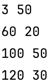

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task1/input3.png"/>  |  <img src="task1/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00086 seconds  | 0.01898 megabytes  |
| Пример из условия                                              | 0.00103 seconds  | 0.02506 megabytes  |
| Пример из условия                                              | 0.00112 seconds  | 0.02527 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 1.05803 seconds  | 15.62256 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализованы три варианта обхода дерева, каждый рабоатет за время - O(n), где n - кол-во узлов дерева.

</div>

### **Задача №3. Простейшее BST [1 балла]**

<div align="justify">

В этой задаче вам нужно написать простейшее BST по явному ключу и отвечать им на запросы:

* «+ x» - добавить в дерево x (если x уже есть, ничего не делать).
* «> x» - вернуть минимальный элемент больше x или 0, если таких нет.

* **Формат ввода / входного файла (input.txt).**

В каждой строке содержится один запрос. Все x - целые числа, количество запросов N не указано в начале, не более 300 000. Гарантируется, что все x выбраны равномерным распределением.

Случайные данные! Не нужно ничего специально балансировать.

* **Ограничения на входные данные.**

1 ≤ x ≤ 10<sup>9</sup>, 1 ≤ N ≤ 300000

* **Формат вывода / выходного файла (output.txt).**

Для каждого запроса вида «> x» выведите в отдельной строке ответ.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [20]:
class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя


class BST:
    def __init__(self):
        self.root = None  # ссылка на корень дерева

    def insert(self, key):
        """
        Вставка узла в дерево

        Замечание: узел всегда добавляется в листья

        Сложность: O(h), где h — высота дерева
        """
        new_node = Node(key)  # создаем новый узел

        # если дерево пустое
        if self.root is None:
            # новый узел становится корнем
            self.root = new_node
            return

        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        parent = None  # переменная для отслеживания родителя

        # ищем место для вставки

        # идем по дереву пока не дошли до листа
        while runner:
            # запоминаем родителя, то есть откуда пришли
            parent = runner

            if key < runner.key:
                runner = runner.left
            elif key > runner.key:
                runner = runner.right
            else:
                return  # нужно, чтобы все элементы дерева были уникальны

        # вставка

        new_node.parent = parent  # назначаем родителя для нового узла
        if key < parent.key:
            # вставка слева
            parent.left = new_node
        else:
            # вставка справа
            parent.right = new_node

    def find_nearest_larger(self, key):
        """
        Возвращает минимальный элемент больший ключа key

        Сложность: O(h), где h - высота дерева
        """
        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        nearest_larger = None  # узел с минимальным ключом большим ключа key

        # идем по дереву пока не дошли до листа
        while runner:
            if key < runner.key:
                nearest_larger = runner  # обновляем минимум
                runner = runner.left
            else:
                runner = runner.right

        # возвращаем минимальный элемент больше key или 0, если таких нет
        return nearest_larger.key if nearest_larger else 0


@time_and_memory_decorator
def main():
    bst_tree = BST()

    with open('task3/input.txt', 'r') as file_input, open('task3/output.txt', 'w') as file_output:
        while line := file_input.readline():
            cmd, number = line.split()
            number = int(number)

            if cmd == '+':
                bst_tree.insert(number)
            elif cmd == '>':
                result = bst_tree.find_nearest_larger(number)
                file_output.write(str(result) + '\n')


main()

Spent time: 1.09253 seconds
Spent memory: 17.81496 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Реализовано двоичное дерево поиска (BST), которое поддерживает две операции: добавление элемента и поиск минимального элемента, строго большего заданного. Все элементы в дереве должны быть уникальными.

Вводим класс узла дерева - Node, где каждый узел хранит ключ и ссылки на левого и правого потомков, а также на родителя.
Класс BST хранит ссылку на корень дерева и реализует основные операции.

Операция вставки нового узла: создаем новый узел, после чего с помощью указателя runner проходим по дереву от корня до листа, на каждом шаге выбирая направление - влево, если ключ меньше текущего, или вправо, если больше. Также запоминаем родителя текущего узла. Когда доходим до листа, вставляем туда новый узел и назначаем ему найденного на последнем шаге родителя. Если элемент с таким ключом уже есть в дереве, то ничего не делаем.

Операция поиска ближайшего большего элемента: используем переменную nearest_larger, в которой храним кандидата на ответ. Если текущий узел имеет ключ больше заданного, он может быть ответом, поэтому сохраняем его и переходим влево, чтобы попытаться найти еще меньший подходящий элемент. Если же ключ текущего узла меньше или равен заданному, то переходим вправо. В результате мы найдем минимальный элемент, больший заданного, либо вернем 0, если такого элемента нет.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task3/input1.png"/>  |  <img src="task3/output1.png"/>  |
|  <img src="task3/input2.png"/>  |  <img src="task3/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task3/input3.png"/>  |  <img src="task3/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00079 seconds  | 0.02657 megabytes  |
| Пример из условия                                              | 0.00094 seconds  | 0.02721 megabytes  |
| Пример из условия                                              | 0.00074 seconds  | 0.02818 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 1.09253 seconds  | 17.81496 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализовано простейшее бинарное дерево поиска с возможностью добавления элементов и поска минимального элемента больше с ключом больше заданного за время - O(h), где h - высота дерева.

</div>

### **Задача №12. Проверка сбалансированности [2 балла]**

<div align="justify">

АВЛ-дерево является сбалансированным в следующем смысле: для любой вершины высота ее левого поддерева отличается от высоты ее правого поддерева не больше, чем на единицу.

Введем понятие баланса вершины: для вершины дерева V ее баланс B(V) равен разности высоты правого поддерева и высоты левого поддерева. Таким образом, свойство АВЛ-дерева, приведенное выше, можно сформулировать следующим образом: для любой ее вершины V выполняется следующее неравенство:

-1 ≤ B(V) ≤ 1

Обратите внимание, что, по историческим причинам, определение баланса в этой и последующих задачах этой недели «зеркально отражено» по сравнению с определением баланса в лекциях! Надеемся, что этот факт не доставит Вам неудобств. В литературе по алгоритмам - как российской, так и мировой - ситуация, как правило, примерно та же.

Дано двоичное дерево поиска. Для каждой его вершины требуется определить ее баланс.

* **Формат ввода / входного файла (input.txt).**

Входной файл содержит описание двоичного дерева.

В первой строке файла находится число N - число вершин в дереве. В последующих N строках файла находятся описания вершин дерева. В (i + 1)-ой строке файла (1 ≤ i ≤ N) находится описание i-ой вершины, состоящее из трех чисел K<sub>i</sub>, L<sub>i</sub>, R<sub>i</sub>, разделенных пробелами - ключа K<sub>i</sub> в i-ой вершине, номера левого L<sub>i</sub> ребенка i-ой вершины (i &lt; L<sub>i</sub> ≤ N или L<sub>i</sub> = 0, если левого ребенка нет) и номера правого R<sub>i</sub> ребенка i-ой вершины (i &lt; R<sub>i</sub> ≤ N или R<sub>i</sub> = 0, если правого ребенка нет). Все ключи различны. Гарантируется, что данное дерево является деревом поиска.

* **Ограничения на входные данные.**

0 ≤ N ≤ 2 · 10<sup>5</sup>,
|K<sub>i</sub>| ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt).**

Для i-ой вершины в i-ой строке выведите одно число - баланс данной вершины.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [4]:
def find_root(n, lefts, rights):
    # ищем корень дерева, так как по условию не сказано, где он
    # корнем является та вершина, на которую никто не ссылается как на ребенка
    children = set()

    # перебираем узлы и добавдяем их детей в мн-во
    for i in range(n):
        if lefts[i] != -1:
            children.add(lefts[i])
        if rights[i] != -1:
            children.add(rights[i])

    root = 0
    for i in range(n):
        # как только нашли узел, который не является ребенком никакого узла - то это root
        if i not in children:
            root = i
            break

    return root


@time_and_memory_decorator
def balance_factor(n, lefts, rights):
    # если дерево пусто
    if n == 0:
        return []

    heights = [0 for _ in range(n)]  # сохраняем высоты каждого узла
    balances = [0 for _ in range(n)]  # сохраняем balance_factor каждого узла

    # получаем порядок обработки post-order, чтобы последовательно вычислять высоты
    # сначала найдем порядок корень -> право -> лево (обратный pre-order) и развернем его,
    # тогда получим post-order порядок лево -> право -> корень
    post_order = []

    root = find_root(n, lefts, rights)  # корень
    stack = [root]  # кладем корень с стек

    # пока просмотрели не все элементы
    while stack:
        v = stack.pop()  # извлекаем элемент из стека
        post_order.append(v)  # сохраняем значение узла

        # сначала кладем левого ребенка, потом правого, чтобы правый узел был сверху стека и мы его достали первым

        # если левый ребенок существует
        if lefts[v] != -1:
            stack.append(lefts[v])  # сохраняем левый узел в стек
        # если правый ребенок существует
        if rights[v] != -1:
            stack.append(rights[v])  # сохраняем правый узел в стек

    # идем по узлам снизу вверх
    while post_order:
        v = post_order.pop()  # просматриваем post_order с конца, чтобы как бы развернуть его

        left, right = lefts[v], rights[v]

        left_height = heights[
            left] if left != - 1 else 0  # если left = -1, то ребенка нет, а значит высота такого поддерева = 0
        right_height = heights[
            right] if right != -1 else 0  # если right = -1, то ребенка нет, а значит высота такого поддерева = 0

        balances[v] = right_height - left_height  # обновляем balance_factor узла v
        heights[v] = max(left_height, right_height) + 1  # обновляем высоту узла v

    return balances


def main():
    with open('task12/input.txt', 'r') as file_input, open('task12/output.txt', 'w') as file_output:
        n = int(file_input.readline())

        keys = [0 for _ in range(n)]
        lefts = [0 for _ in range(n)]
        rights = [0 for _ in range(n)]

        for i in range(n):
            k, l, r = map(int, file_input.readline().split())
            keys[i] = k
            lefts[i] = l - 1  # делаем -1 для упрощения индексации
            rights[i] = r - 1  # делаем -1 для упрощения индексации

        result = balance_factor(n, lefts, rights)

        file_output.write("\n".join(map(str, result)))


main()

Spent time: 0.00002 seconds
Spent memory: 0.00041 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Сначала определяем какой узел является корнем - это тот узел, который не является ребенком ни одного другого узла.

Вычисляем высоты поддеревьев для каждой вершины, начиная с листьев. Чтобы не пересчитывать высоты много раз, используем post-order обход дерева. С помощью стека формируем порядок обхода вершин: добавляем корень в стек, затем последовательно обрабатываем его потомков, и все вершины записываем в массив. После этого массив обрабатываем в обратном порядке, чтобы как раз получить post-order обход (left -> right -> root). Для каждой вершины берем уже посчитанные высоты левого и правого поддеревьев, вычисляем баланс этих высот (height(right) - height(left)), а затем находим высоту самой вершины как максимум из высот поддеревьев + 1 (учитываем сам этот узел).
</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task12/input1.png"/>  | <img src="task12/output1.png"/>  |
| <img src="task12/input2.png"/>  | <img src="task12/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task12/input3.png"/>  | <img src="task12/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00000 seconds  | 0.00000 megabytes  |
| Пример из условия                                              | 0.00003 seconds  | 0.00023 megabytes  |
| Пример из условия                                              | 0.00003 seconds  | 0.00023 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.54945 seconds  | 16.82266 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм нахождения balance_factor для всех вершин дерева за время - O(n), где n - кол-во узлов дерева.

</div>

### **Задача №17. Множество с суммой [3 балла]**

<div align="justify">

В этой задаче ваша цель - реализовать структуру данных для хранения набора целых чисел и быстрого вычисления суммы элементов в заданном диапазоне.

Реализуйте такую структуру данных, в которой хранится набор целых чисел S и доступны следующие операции:

* add(i) - добавить число i в множество S. Если i уже есть в S, то ничего делать не надо;
* del(i) - удалить число i из множества S. Если i нет в S, то ничего делать не надо;
* find(i) - проверить, есть ли i во множестве S или нет;
* sum(l, r) - вывести сумму всех элементов v из S таких, что l ≤ v ≤ r.

* **Формат ввода / входного файла (input.txt).**

Изначально множество S пусто. Первая строка содержит n - количество операций. Следующие n строк содержат операции. Однако, чтобы убедиться, что ваше решение может работать в режиме онлайн, каждый запрос фактически будет зависеть от результата последнего запроса суммы.

Обозначим M = 1 000 000 001. В любой момент пусть x будет результатом последней операции суммирования или просто 0, если до этого операций суммирования не было. Тогда каждая операция будет являться одной из следующих:

* «+ i» - добавить некое число в множество S. Но не само число i, а число ((i + x) mod M).
* «- i» - удалить из множества S, т.е. del((i + x) mod M).
* «? i» - find((i + x) mod M).
* «s l r» - вывести сумму всех элементов множества S из определенного диапазона, т.е. sum((l + x) mod M, (r + x) mod M).

* **Ограничения на входные данные.**

1 ≤ n ≤ 100000, 1 ≤ i ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt).**

Для каждого запроса «find», выведите только «Found» или «Not found» (без кавычек, первая буква заглавная) в зависимости от того, есть ли число ((i + x) mod M) в S или нет.

Для каждого запроса суммы «sum» выведите сумму всех значений v из S из диапазона (l + x) mod M ≤ v ≤ (r + x) mod M, где x - результат подсчета прошлой суммы «sum», или 0, если еще не было таких операций.

* **Ограничение по времени.**

120 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [9]:
"""
Splay дерево с уникальными элементами

Splay дерево имеет амортизированную сложность O(log(n)), то есть
одна операция может быть дорогой - O(n), НО последовательность из m операций занимает - O(mlog(n)) в среднем
"""


class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя
        self.sum = key  # сумма поддерева, включая сам узел


class SplayTree:
    def __init__(self):
        self.root = None  # корень дерева

    def update(self, node):
        """
        Обновление информации узла после каждого изменения дерева

        Сложность: O(1)
        """
        # если пытаемся обновить несуществующий узел
        if node is None:
            return

        # обновляем сумму узла, родственные связи узла и его (новых) детей

        node.sum = node.key  # изначально ставим сумму для узла равную его ключу

        # если есть левый ребенок
        if node.left:
            node.sum += node.left.sum  # добавляем сумму левого поддерева
            node.left.parent = node  # синхронизируем родителя для левого поддерева
        # если есть правый ребенок
        if node.right:
            node.sum += node.right.sum  # добавляем сумму правого поддерева
            node.right.parent = node  # синхронизируем родителя правого поддерева

    def small_rotation(self, node):
        r"""
        Малые вращения - Zig

        Алгоритм: меняем узел node с его родителем parent,
        - Операция Zig: если узел является левым ребенком родителя, выполняем на родителе правый поворот, иначе – левый поворот

        Замечание1: НУЖНО СОХРАНЯТЬ СВОЙСТВО BST
        Замечание2: Все остальные узлы которые не указаны в примерах остаются на тех же местах

        ---------------------------------------
        Zig

        Правое вращение:
        До:              После:
           parent           node
          /                    \
         node                 parent
          \                    /
           child            child

        Левое вращение:
        До:              После:
          parent             node
            \                /
            node          parent
            /               \
          child             child

        ---------------------------------------
        Сложность: O(1)
        """
        parent = node.parent  # запоминаем родителя node
        if parent is None:  # node - корень дерева
            return

        grandparent = parent.parent  # запоминаем родителя parent

        # если node слева
        if parent.left == node:
            child = node.right  # запоминаем правого ребенка node
            node.right = parent  # делаем parent правым ребенком node
            parent.left = child  # делаем child левым ребенком parent
        # если node справа
        else:
            child = node.left  # запоминаем левого ребенка node
            node.left = parent  # делаем parent левым ребенком node
            parent.right = child  # делаем child правым ребенком parent

        self.update(parent)  # СНАЧАЛА выполняем актуализацию данных узла parent
        self.update(node)  # ЗАТЕМ выполняем актуализацию данных узла node

        node.parent = grandparent  # обновляем родителя node

        if grandparent:  # если grandparent - НЕ корень дерева
            # подвязываем к grandparent его ребенка - node
            if grandparent.left == parent:
                grandparent.left = node
            else:
                grandparent.right = node

    def big_rotation(self, node):
        r"""
        Большие вращения - Zig-Zig и Zig-Zag

        Алгоритм: выполняем два малых вращения подряд, чтобы поднять узел node на два уровня вверх (меняем местами node, parent и grandparent)
        - Операция Zig-Zig: сначала выполним Zig для родителя, затем выполним Zig для нашего узла
        - Операция Zig-Zag: выполним Zig для нашего узла, затем сделаем это еще раз

        Zig-Zig -> линия -> поднимаем parent -> поднимаем node
        Zig-Zag -> угол -> два раза поднимаем node

        Замечание1: НУЖНО СОХРАНЯТЬ СВОЙСТВО BST
        Замечание2: Все остальные узлы которые не указаны в примерах учитываются уже при применении small_rotation

        ---------------------------------------
        Zig-Zig (линейный случай)

        Оба слева:
        До:                    После:
                grandparent        node
                /                  \
             parent               parent
             /                      \
           node                  grandparent

        Оба справа:
        До:                    После:
            grandparent          node
                 \              /
                parent        parent
                   \          /
                   node    grandparent

        ---------------------------------------
        Zig-Zag (угловой случай)

        Лево-право:
        До:                    После:
              grandparent          node
              /                   /    \
           parent               parent  grandparent
              \
              node

        Право-лево:
        До:                    После:
           grandparent            node
                \                /    \
               parent         grandparent parent
               /
             node

        ---------------------------------------
        Сложность: O(1)
        """
        parent = node.parent  # родитель узла node
        grandparent = parent.parent  # прародитель узла node

        # Zig-Zig
        # лево-лево:
        if parent.left == node and grandparent.left == parent:
            self.small_rotation(parent)
            self.small_rotation(node)
        # право-право:
        elif parent.right == node and grandparent.right == parent:
            self.small_rotation(parent)
            self.small_rotation(node)
        # Zig-Zag
        else:
            self.small_rotation(node)
            self.small_rotation(node)

    def splay(self, node):
        """
        Цикл из вращений, который поднимает узел node в корень дерева с помощью Zig / Zig-Zig / Zig-Zag
        Каждая итерация поднимает node на 1 или 2 уровня вверх

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если пытаемся поднять несуществующий узел
        if node is None:
            return None

        # пока node не стал корнем
        while node.parent:
            # если у node есть parent, но нет grandparent
            if node.parent.parent is None:
                self.small_rotation(node)  # Zig
            # если у node есть parent и grandparent
            else:
                self.big_rotation(node)  # Zig-Zig / Zig-Zag

        return node  # возвращаем новый root

    def search(self, runner, key):
        r"""
        Поиск узла с ключом key по поддереву с корнем runner, который приводит дерево к виду:
              last_visited_node (<= key)
                  /         \
               < key       nearest_larger_node (>= key)
                                \
                                >= key

        Замечание 1: last_visited_node <= key, потому что last_visited_node и nearest_larger_node могут быть одним и тем же узлом после завершения поиска

        Замечание 2: Фактически это похоже на бинарный поиск по двоичному дереву поиска, так как
        - все дети last_visited_node, включая его будут <= key
        - все дети nearest_larger_node, включая его будут >= key

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # начинаем поиск узла с ключом key с корня runner переданного поддерева

        last_visited_node = runner  # последний посещенный узел, который будет <= искомого узла с ключом key
        nearest_larger_node = None  # наименьший (ближайший) узел, который >= искомого узла с ключом key

        # пока не упремся в None
        while runner:
            last_visited_node = runner  # обновляем последний посещенный узел, который будет <= искомого узла с ключом key

            # если ключ текущего узла >= искомого
            if runner.key >= key:
                nearest_larger_node = runner  # обновляем ближайший узел, который >= искомого узла с ключом key
                runner = runner.left  # идем к меньшим узлам (влево)
            # если ключ текущего узла < искомого
            else:
                runner = runner.right  # идем к большим узлам (вправо)

        root = self.splay(
            last_visited_node)  # последний посещенный узел, который будет <= искомого узла с ключом key, в корень для балансировки (амортизации)

        return nearest_larger_node, root

    def split(self, root, key):
        r"""
        Разделение поддерева с корнем root на два поддерева left и right:
        - left: < key
        - right: >= key

        Пример:
            Делаем поиск по ключу 26:
                До разбиения:       После разбиения:
                        25             left:      right:
                       /  \               25          30
                     20    30             /
                    /                    20
                  10                     /
                                        10

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если поддерево пусто
        if root is None:
            # возвращаем левое и правое поддеревья пустыми
            return None, None

        # выполняем поиск и подготавливаем дерево к разбиению приводя его к виду:
        # - все дети last_visited_node, включая его будут <= key
        # - все дети nearest_larger_node, включая его будут >= key
        nearest_larger_node, root = self.search(root, key)

        # если в дереве нет элементов >= key, тогда
        # left - все дерево, right - None
        if nearest_larger_node is None:
            return root, None

        # поднимаем nearest_larger_node в корень, чтобы:
        # - все элементы < key были в левом поддереве
        # - все элементы >= key были в корне и справа
        right = self.splay(nearest_larger_node)

        # выделяем левое поддерево
        left = right.left

        # делаем разрез, разрывая дерево на две части
        right.left = None

        # если левое поддерево не пусто
        if left:
            # удаляем ссылку на старого родителя у корня поддерева left
            left.parent = None

        self.update(left)  # пересчет суммы левого поддерева, так как произошло разбиение
        self.update(right)  # пересчет суммы правого поддерева, так как произошло разбиение

        return left, right  # возвращаем полученные поддеревья

    def merge(self, left, right):
        r"""
        Слияние двух поддеревьев, причем изначально все ключи в поддереве left < ключей в поддереве right

        Что произойдет после вызова метода:
                left        right
                      (?) <--------
                     /   \        |
                    3     9       |
                   / \     \      |
                  2   5     11    |
                 /   / \    /     |
                1   4   7  10     |
                       / \        |
                      6  (8) -----

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если левое поддерево пусто
        if left is None:
            return right
        # если правое поддерево пусто
        if right is None:
            return left

        # получаем корень нового дерева, беря в качестве него самый большой узел левого поддерева
        node = left
        while node.right:
            node = node.right

        # поднимаем найденный узел в корень левого поддерева
        left = self.splay(node)

        left.right = right  # подвязываем правое поддерево к корню нового дерева
        right.parent = left  # изменяем родителя правого ребенка left на left

        self.update(left)  # актуализируем данные узла left, то есть нового корня

        return left  # возвращаем корень собранного дерева

    def add(self, key):
        r"""
        Добавление узла с заданным ключом key в дерево, если там еще нет узла с таким ключом

        Пример:
        До:
            20
           /  \
         10    30

        Вставим 25:
            Шаг 1:
                left:        right:
                   20           30
                  /
                10

                self.merge(left, new_node), new_node = 25

                   20
                  /  \
                10    25
            Шаг 2:
                self.root = self.merge(self.merge(left, new_node), right)

                        25
                       /  \
                     20    30
                    /
                  10

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        left, right = self.split(self.root, key)  # разбиваем дерево на два поддерева < key и >= key

        # если узел с таким ключом уже есть в дереве
        if right and right.key == key:
            # просто склеиваем две части обратно
            self.root = self.merge(left, right)
            return

        # если узла с таким ключом еще нет в дереве
        new_node = Node(key)  # создаем новый узел

        # объединяем новый узел с левым поддеревом, а затем полученное поддерево с правым поддеревом
        self.root = self.merge(self.merge(left, new_node), right)

    def delete(self, key):
        """
        Удаление узла с заданным ключом key из дерева, если узел с таким ключом есть в дереве

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        node, self.root = self.search(self.root, key)  # находим узел для удаления

        # если узла с таким ключом нет в дереве
        if node is None or node.key != key:
            return

        self.root = self.splay(node)  # поднимаем найденный узел в корень дерева

        left = self.root.left  # отделяем левое поддерево
        right = self.root.right  # отделяем правое поддерево

        # если левое поддерево не пусто
        if left:
            # убираем связь с предыдущим родителем
            left.parent = None
        # если правое поддерево не пусто
        if right:
            # убираем связь с предыдущим родителем
            right.parent = None

        # склеиваем левое и правое поддеревья между мобой
        self.root = self.merge(left, right)

    def range_sum(self, left_bound, right_bound):
        """
        Нахождение суммы узлов дерева, которые по значению ключей попадают в отрезок [left_bound; right_bound]

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        left, middle = self.split(self.root,
                                  left_bound)  # разбиваем дерево на левое < left_bound и среднее >= left_bound
        middle, right = self.split(middle,
                                   right_bound + 1)  # разбиваем дерево на среднее <= right_bound и правое >= right_bound + 1

        result = 0  # сумма в отрезке [left_bound; right_bound]

        # если поддерево узлов значения которых принадлежат отрезку [left_bound; right_bound] не пусто
        if middle:
            result = middle.sum

        # склеиваем поддеревья обратно
        self.root = self.merge(left, self.merge(middle, right))

        return result

    def find(self, key):
        """
        Возвращает ответ пользователю о существовании запрашиваемого узла с ключом key в дереве
        """
        node, self.root = self.search(self.root, key)

        # узел с ключом key есть
        if node and node.key == key:
            return True

        return False  # узла c ключом key нет


@time_and_memory_decorator
def main():
    MOD = 1_000_000_001
    splay_tree = SplayTree()

    with open('task17/input.txt', 'r') as file_input, open('task17/output.txt', 'w') as file_output:
        n = int(file_input.readline())
        last_sum = 0  # результат последней операции суммирования

        for _ in range(n):
            line = file_input.readline().split()
            if line[0] == '+':
                number = (int(line[1]) + last_sum) % MOD
                splay_tree.add(number)
            elif line[0] == '-':
                number = (int(line[1]) + last_sum) % MOD
                splay_tree.delete(number)
            elif line[0] == '?':
                number = (int(line[1]) + last_sum) % MOD
                found = splay_tree.find(number)
                file_output.write(("Found" if found else "Not found") + '\n')
            else:
                left_bound = (int(line[1]) + last_sum) % MOD
                right_bound = (int(line[2]) + last_sum) % MOD

                # за счет взятия остатка от деления, левая гарница может стать меньше правой
                if left_bound > right_bound:
                    left_bound, right_bound = right_bound, left_bound

                result = splay_tree.range_sum(left_bound, right_bound)
                file_output.write(str(result) + '\n')

                last_sum = result % MOD  # делаем остаток от деления, чтобы уменьшить числа, так как потом мы все равно будем брать все действия по модулю MOD


main()

Spent time: 0.00068 seconds
Spent memory: 0.09243 megabytes


**Текстовое объяснение решения:**

<div align="justify">

* **Структура данных** - каждый узел Node имеет поле key для значения, ссылки на левого и правого ребенка, ссылку на родителя и поле sum для суммы поддерева, включая сам узел
* **Splay дерево** - используется для хранения уникальных элементов, имеет амортизированную сложность O(log(n)), одна операция может быть дорогой - O(n), но последовательность из m операций занимает O(m log(n)) в среднем
* **update(node)** - обновление информации узла после каждого изменения дерева
* **small_rotation(node)** - малые вращения (Zig)
* **big_rotation(node)** - большие вращения (Zig-Zig и Zig-Zag)
* **splay(node)** - цикл из вращений, который поднимает узел node в корень дерева с помощью Zig / Zig-Zig / Zig-Zag
* **search(root, key)** - поиск по дереву, который приводит дерево к виду last_visited_node (<= key) / nearest_larger_node (>= key)
* **split(root, key)** - разделение дерева на два поддерева left и right: left < key, right >= key
* **merge(left, right)** - слияние двух поддеревьев, причем все ключи в поддереве left < ключей в поддереве right
* **add(key)** - добавление узла с заданным ключом key в дерево, если там еще нет узла с таким ключом
* **delete(key)** - удаление узла с заданным ключом key из дерева, если узел с таким ключом есть
* **range_sum(left_bound, right_bound)** - нахождение суммы узлов дерева, которые по значению ключей попадают в отрезок [left_bound; right_bound]
* **find(key)** - возвращает ответ пользователю о существовании запрашиваемого узла с ключом key в дереве

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task17/input1.png"/>  | <img src="task17/output1.png"/>  |
| <img src="task17/input2.png"/>  | <img src="task17/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task17/input3.png"/>  | <img src="task17/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00060 seconds  | 0.09222 megabytes |
| Пример из условия                                              | 0.00105 seconds  | 0.09222 megabytes |
| Пример из условия                                              | 0.00073 seconds  | 0.09222 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.48923 seconds  | 0.12511 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализованная структура данных - Splay дерево с уникальными значениями. Splay дерево имеет амортизированную сложность O(log(n)), то есть одна операция может быть дорогой - O(n), но последовательность из m операций занимает - O(mlog(n)) в среднем.

</div>

<h1></h1>

<div align="center">

# **Дополнительные задачи**

</div>

---

### **Задача №18. Веревка [5 балла]**

<div align="justify">

В этой задаче вы реализуете Веревку (или Rope) - структуру данных, которая может хранить строку и эффективно вырезать часть (подстроку) этой строки и вставлять ее в другое место. Эту структуру данных можно улучшить, чтобы она стала персистентной, то есть чтобы разрешить доступ к предыдущим версиям строки. Эти свойства делают ее подходящим выбором для хранения текста в текстовых редакторах.

Это очень сложная задача, более сложная, чем почти все предыдущие сложные задачи этого курса.

Вам дана строка S, и вы должны обработать n запросов. Каждый запрос описывается тремя целыми числами i, j, k и означает вырезание подстроки S[i...j] (здесь индексы i и j в строке считаются от 0) из строки и вставка ее после k-го символа оставшейся строки (как бы символы в оставшейся строке нумеруются с 1). Если k = 0, S[i...j] вставляется в начало. Дополнительные пояснения смотрите в примерах.

* **Формат ввода / входного файла (input.txt).**

В первой строке ввода содержится строка S. Вторая строка содержит количество запросов n. Следующие n строк содержат по три целых числа i, j, k.

* **Ограничения на входные данные.**

Строка S содержит только английские строчные буквы. 1 ≤ |S| ≤ 300000, 1 ≤ n ≤ 100000, 0 ≤ i ≤ j ≤ |S| − 1, 0 ≤ k ≤ |S| − (j − i + 1).

* **Формат вывода / выходного файла (output.txt).**

Выведите строку после выполнения n запросов.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [11]:
r"""
Структура данных Rope на основе Splay дерева

Будем хранить строку как in-order последовательность (тогда после in-order обхода дерева) мы будем получать строку целиком, а индекс символа строки тогда будем отсчитывать через размеры поддеревьев.
Доступ к символу строки по индексу осуществляем через спуск по дереву.

Так как порядок хранения строки задается in-order обходом, то одна и та же строка может храниться в разных деревьях:
Вариант 1:        Вариант 2:
        d                   c
      /   \              /    \
     b     f            a      e
    /  \   /             \    /  \
   a    c  e              b  d   f
    in-order:       in-order:
        abcdef         abcdef

Структура дерева зависит от порядка вставок, операций splay, split, merge

Замечание 1: индексация узлов дерева начинается с 0.
Замечание 2: ключи в данной задаче не явные и являются индексами узлов дерева (то есть индексами символов исх. стр.)
"""


class Node:
    def __init__(self, char):
        self.char = char  # символ строки, который хранится в этом узле
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя
        self.size = 1  # количество элементов в поддереве, включая корень этого поддерева


class Rope:
    def __init__(self):
        self.root = None  # корень дерева

    def update(self, node):
        """
        Обновление информации узла после каждого изменения дерева

        Сложность: O(1)
        """
        # если пытаемся обновить несуществующий узел
        if node is None:
            return

        # обновляем размер поддерева с корнем в этом узле, родственные связи узла и его (новых) детей

        node.size = 1  # изначально ставим размер поддерева равным 1

        # если есть левый ребенок
        if node.left:
            node.size += node.left.size  # добавляем размер левого поддерева
            node.left.parent = node  # синхронизируем родителя для левого поддерева
        # если есть правый ребенок
        if node.right:
            node.size += node.right.size  # добавляем размер правого поддерева
            node.right.parent = node  # синхронизируем родителя правого поддерева

    def small_rotation(self, node):
        r"""
        Малые вращения - Zig

        Алгоритм: меняем узел node с его родителем parent,
        - Операция Zig: если узел является левым ребенком родителя, выполняем на родителе правый поворот, иначе – левый поворот

        Замечание1: НУЖНО СОХРАНЯТЬ СВОЙСТВО BST
        Замечание2: Все остальные узлы которые не указаны в примерах остаются на тех же местах

        ---------------------------------------
        Zig

        Правое вращение:
        До:              После:
           parent           node
          /                    \
         node                 parent
          \                    /
           child            child

        Левое вращение:
        До:              После:
          parent             node
            \                /
            node          parent
            /               \
          child             child

        ---------------------------------------
        Сложность: O(1)
        """
        parent = node.parent  # запоминаем родителя node
        if parent is None:  # node - корень дерева
            return

        grandparent = parent.parent  # запоминаем родителя parent

        # если node слева
        if parent.left == node:
            child = node.right  # запоминаем правого ребенка node
            node.right = parent  # делаем parent правым ребенком node
            parent.left = child  # делаем child левым ребенком parent
        # если node справа
        else:
            child = node.left  # запоминаем левого ребенка node
            node.left = parent  # делаем parent левым ребенком node
            parent.right = child  # делаем child правым ребенком parent

        self.update(parent)  # СНАЧАЛА выполняем актуализацию данных узла parent
        self.update(node)  # ЗАТЕМ выполняем актуализацию данных узла node

        node.parent = grandparent  # обновляем родителя node

        if grandparent:  # если grandparent - НЕ корень дерева
            # подвязываем к grandparent его ребенка - node
            if grandparent.left == parent:
                grandparent.left = node
            else:
                grandparent.right = node

    def big_rotation(self, node):
        r"""
        Большие вращения - Zig-Zig и Zig-Zag

        Алгоритм: выполняем два малых вращения подряд, чтобы поднять узел node на два уровня вверх (меняем местами node, parent и grandparent)
        - Операция Zig-Zig: сначала выполним Zig для родителя, затем выполним Zig для нашего узла
        - Операция Zig-Zag: выполним Zig для нашего узла, затем сделаем это еще раз

        Zig-Zig -> линия -> поднимаем parent -> поднимаем node
        Zig-Zag -> угол -> два раза поднимаем node

        Замечание1: НУЖНО СОХРАНЯТЬ СВОЙСТВО BST
        Замечание2: Все остальные узлы которые не указаны в примерах учитываются уже при применении small_rotation

        ---------------------------------------
        Zig-Zig (линейный случай)

        Оба слева:
        До:                    После:
                grandparent        node
                /                  \
             parent               parent
             /                      \
           node                  grandparent

        Оба справа:
        До:                    После:
            grandparent          node
                 \              /
                parent        parent
                   \          /
                   node    grandparent

        ---------------------------------------
        Zig-Zag (угловой случай)

        Лево-право:
        До:                    После:
              grandparent          node
              /                   /    \
           parent               parent  grandparent
              \
              node

        Право-лево:
        До:                    После:
           grandparent            node
                \                /    \
               parent         grandparent parent
               /
             node

        ---------------------------------------
        Сложность: O(1)
        """
        parent = node.parent  # родитель узла node
        grandparent = parent.parent  # прародитель узла node

        # Zig-Zig
        # лево-лево:
        if parent.left == node and grandparent.left == parent:
            self.small_rotation(parent)
            self.small_rotation(node)
        # право-право:
        elif parent.right == node and grandparent.right == parent:
            self.small_rotation(parent)
            self.small_rotation(node)
        # Zig-Zag
        else:
            self.small_rotation(node)
            self.small_rotation(node)

    def splay(self, node):
        """
        Цикл из вращений, который поднимает узел node в корень дерева с помощью Zig / Zig-Zig / Zig-Zag
        Каждая итерация поднимает node на 1 или 2 уровня вверх

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если пытаемся поднять несуществующий узел
        if node is None:
            return None

        # пока node не стал корнем
        while node.parent:
            # если у node есть parent, но нет grandparent
            if node.parent.parent is None:
                self.small_rotation(node)  # Zig
            # если у node есть parent и grandparent
            else:
                self.big_rotation(node)  # Zig-Zig / Zig-Zag

        return node  # возвращаем новый root

    def search_by_index(self, root, requested_index):
        """
        Найти символ строки под индексом requested_index (индексация в строке начинается с 0) и поднять его в корень для балансировки (амортизации)

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        node = root  # начинаем поиск символа под индексом requested_index с корня дерева
        # Замечание: начинать поиск не с корня всего дерева не имеет смысла, так как индексы исходной строки будут неправильными, ведь с 0 индексы начинаются только во всем дереве

        # пока не дойдем до листа спускаемся по дереву
        while node:
            left_size = node.left.size if node.left else 0  # кол-во элементов левее текущего узла

            # если индекс совпал, то мы нашли нужный узел
            if requested_index == left_size:
                # поднимаем найденный узел в корень, чтобы сделать доступ к нему быстрее при следующих запросах
                return self.splay(node)
            # символ под индексом requested_index в левом поддереве
            elif requested_index < left_size:
                node = node.left  # идем к меньшим индексам строки (влево)
            # символ под индексом k requested_index правом поддереве
            else:
                requested_index -= (left_size + 1)  # перестаем учитывать размер левого поддерева и текущий узел
                node = node.right  # идем к большим индексам строки (вправо)

        return None  # если ничего не нашли, то есть если индекс requested_index был >= длины строки или < 0

    def split(self, root, split_index):
        r"""
        Разделение поддерева с корнем root на два поддерева с символами строки под индексом < split_index и на поддерево с элементами строки под индексами >= split_index:
        - left: символы под индексом < split_index
        - right: символы под индексом >= split_index

        Пример:
        Разбиение по индексу 2:
        До разбиения:       После разбиения:
                c(2)             left:      right:
               /  \               b(1)        c(2)
            b(1)  d(3)             /            \
            /                    a(0)          d(3)
          a(0)

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если поддерево пусто
        if root is None:
            # возвращаем левое и правое поддеревья пустыми
            return None, None

        # если в поддереве с корнем root нет элементов под индексом split_index, тогда нам подходит все поддерево
        # такое может быть в двух случаях:
        # - если split_index < 0, тогда нам подходят все символы поддерева с корнем root
        # - если split_index >= root.size, тогда нам подходят все символы поддерева с корнем root
        if split_index < 0:
            # все элементы будут под индексом >= split_index, то есть идут в правое поддереве
            return None, root
        elif split_index >= root.size:
            # все элементы будут под индексом < split_index, то есть идут в левом поддереве
            return root, None

        # выполняем поиск и подготавливаем деерево к разбиению приводя его к виду:
        # - left: символы под индексом < split_index
        # - right: символы под индексом >= split_index
        right = self.search_by_index(root,
                                     split_index)  # получаем поддерево, в корне которого стоит узел под индексом split_index

        # выделяем левое поддерево
        left = right.left

        # делаем разрез, разрывая дерево на две части
        right.left = None

        # если левое поддерево не пусто
        if left:
            # удаляем ссылку на старого родителя у корня поддерева left
            left.parent = None

        self.update(left)  # пересчет размера левого поддерева, так как произошло разбиение
        self.update(right)  # пересчет размера правого поддерева, так как произошло разбиение

        return left, right  # возвращаем полученные поддеревья

    def merge(self, left, right):
        r"""
        Слияние двух поддеревьев, причем изначально все индексы символов исх. стр. в поддереве left < индексов символов исх. стр. в поддереве right

        Что произойдет после вызова метода:
                left        right
                      (?) <--------
                     /   \        |
                    3     9       |
                   / \     \      |
                  2   5     11    |
                 /   / \    /     |
                1   4   7  10     |
                       / \        |
                      6  (8) -----

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        # если левое поддерево пусто
        if left is None:
            return right
        # если правое поддерево пусто
        if right is None:
            return left

        # получаем корень нового дерева, беря в качестве него узел символа под самым большим индексом левого поддерева
        node = left
        while node.right:
            node = node.right

        # поднимаем найденный узел в корень левого поддерева
        left = self.splay(node)

        left.right = right  # подвязываем правое поддерево к корню нового дерева
        right.parent = left  # изменяем родителя правого ребенка left на left

        self.update(left)  # актуализируем данные узла left, то есть нового корня

        return left  # возвращаем корень собранного дерева

    def cut_and_paste(self, left_index, right_index, paste_index):
        r"""
        Вырезает кусок строки под индексами [left_index; right_index] и вставляет вырезанный кусок по индексу paste_index в полученное после операции выреза дерево

        Пример:
            Было:
                Исходная строка = abcdef
                Выделенная подстрока (left_index = 2, right_index = 4) = cde
                left = ab / middle = cde / right = f
                Исходная строка после удаления = abf
                Вставка в paste_index = 1:
                a | bf
            Стало:
                -> a + cde + bf = acdebf

        Сложность: амортизированно O(log(n)), где n - кол-во узлов дерева
        """
        left, middle = self.split(self.root,
                                  left_index)  # разбиваем дерево на левое < left_index и среднее >= left_index
        middle, right = self.split(middle,
                                   right_index - left_index + 1)  # разбиваем дерево на среднее < right_index - left_index + 1 и правое >= right_index - left_index + 1

        # получили:
        # left (символы с индексами < left_index)
        # middle (символы с индексами из [left_index; right_index]
        # right (символы с индексами > right_index)

        # собираем новое дерево без middle части
        self.root = self.merge(left, right)

        # разделяем дерево по индексу paste_index, чтобы потом к левому поддереву добавить middle часть
        left, right = self.split(self.root, paste_index)
        # вставляем middle в позицию paste_index
        self.root = self.merge(self.merge(left, middle), right)

        return self.root  # возвращаем новое дерево

    def in_order_traversal(self, runner):
        r"""
        Симметричный обход (Left -> Runner -> Right)

        Алгоритм: идем влево до конца, потом обрабатываем узел, потом идем вправо до конца

        Пример:
            Дерево:
                    1
                   / \
                  2   3
                 / \ / \
                4  5 6  7
            Inorder (симметричный):
                4 2 5 1 6 3 7

        Сложность: O(n), где n - кол-во узлов дерева
        """
        # если дерево пусто
        if runner is None:
            return []

        result = []
        stack = []

        # если убрать or runner, то правое поддерево последнего узла не будет обработано, если стек к этому моменту пуст
        # условие stack or runner гарантирует, что даже когда стек пуст, но есть ещё узлы для обработки (runner), цикл продолжится
        while stack or runner:
            # если мы не дошли до листа
            if runner:
                stack.append(runner)  # добавляем текущий узел с стек
                runner = runner.left  # идем влево
            # если мы дошли до листа
            else:
                runner = stack.pop()  # извлекаем элемент из стека
                result.append(runner.char)  # сохраняем значение узла
                runner = runner.right  # идем вправо

        return result


@time_and_memory_decorator
def main():
    rope = Rope()

    with open('task18/input.txt', 'r') as file_input, open('task18/output.txt', 'w') as file_output:
        s = file_input.readline()
        n = int(file_input.readline())

        for char in s:
            rope.root = rope.merge(rope.root, Node(char))

        for _ in range(n):
            i, j, k = map(int, file_input.readline().split())
            rope.cut_and_paste(i, j, k)

        result = rope.in_order_traversal(rope.root)
        file_output.write(''.join(result))


main()

Spent time: 0.00056 seconds
Spent memory: 0.02084 megabytes


**Текстовое объяснение решения:**

<div align="justify">

* **Структура данных** – каждый узел Node хранит символ строки char, ссылки на левого и правого ребенка, ссылку на родителя parent и размер поддерева size (количество символов, включая сам узел)
* **Rope на базе Splay дерева** – данная структура данных хорошо подходит для хранения строки и выполнения операций вырезания и вставки подстрок. Доступ к символу по индексу осуществляется через размеры поддеревьев. Амортизированная сложность операций O(log(n)), где n – длина строки
* **update(node)** – обновление информации узла после изменения структуры дерева, пересчет размера поддерева и обновление связи с детьми
* **small_rotation(node)** – малые вращения (Zig) для поднятия узла на один уровень вверх, поддерживая свойства дерева
* **big_rotation(node)** – большие вращения (Zig-Zig и Zig-Zag) для поднятия узла на два уровня вверх, поддерживая свойства дерева
* **splay(node)** – цикл вращений, который поднимает узел в корень дерева, чтобы ускорить доступ к часто используемым символам
* **search_by_index(root, requested_index)** – поиск символа строки по индексу requested_index и подъем его в корень для амортизированной балансировки
* **split(root, split_index)** – разделение дерева на два поддерева: left – символы с индексами < split_index и right – символы с индексами >= split_index
* **merge(left, right)** – слияние двух поддеревьев, где все индексы символов в left меньше, чем в right
* **cut_and_paste(left_index, right_index, paste_index)** – вырез подстроки по индексам [left_index; right_index] и вставка ее после позиции paste_index в новой получившейся строке
* **in_order_traversal(runner)** – симметричный обход дерева (Left -> Node -> Right), возвращает строку в правильном порядке
* Для инициализации строки создаем дерево из исходной строки, добавляя символы исходной строки по очереди с помощью merge

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task18/input1.png"/>  | <img src="task18/output1.png"/>  |
| <img src="task18/input2.png"/>  | <img src="task18/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task18/input3.png"/>  | <img src="task18/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00058 seconds  | 0.08950 megabytes  |
| Пример из условия                                              | 0.00081 seconds  | 0.09036 megabytes  |
| Пример из условия                                              | 0.00073 seconds  | 0.08950 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 3.36816 seconds  | 39.21768 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализованная структура данных - Rope на основе Splay дерева. Rope имеет амортизированную сложность O(log(n)), то есть одна операция может быть дорогой - O(n), но последовательность из m операций занимает - O(mlog(n)) в среднем. Rope используется для хранения строки, данная структура данных представляет из себя двоичное сбалансированное дерево и позволяет выполнять операции вставки, удаления и конкатенации с логарифмической асимптотикой.

</div>

### **Задача №4. Простейший неявный ключ [1 балла]**

<div align="justify">

В этой задаче вам нужно написать BST по неявному ключу и отвечать им на запросы:

* «+ x» - добавить в дерево x (если x уже есть, ничего не делать).
* «? k» - вернуть k-й по возрастанию элемент.

* **Формат ввода / входного файла (input.txt).**

В каждой строке содержится один запрос. Все x - целые числа, количество запросов N не указано в начале, не более 300 000. Гарантируется, что все x выбраны равномерным распределением.

Случайные данные! Не нужно ничего специально балансировать.

* **Ограничения на входные данные.**

1 ≤ x ≤ 10<sup>9</sup>, 1 ≤ N ≤ 300000, в запросах «? k», число k от 1 до количества элементов в дереве.

* **Формат вывода / выходного файла (output.txt).**

Для каждого запроса вида «? k» выведите в отдельной строке ответ.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [29]:
class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя
        self.size = 1  # размер поддерева, включая сам узел


class BST:
    def __init__(self):
        self.root = None  # ссылка на корень дерева

    def get_size(self, node):
        """
        Возвращает размер поддерева, включая сам узел

        Сложность: O(1)
        """
        return node.size if node else 0  # 0 если None

    def update_size(self, runner):
        """
        Обновляем размер поддеревьев проходя снизу вверх

        Сложность: O(h), где h — высота дерева
        """
        # пока не дошли до корня
        while runner:
            left_size = self.get_size(runner.left)  # находимм размер левого поддерева
            right_size = self.get_size(runner.right)  # находимм размер правого поддерева
            runner.size = left_size + right_size + 1  # обновляем размер поддерева с корнем в текущем узле
            runner = runner.parent  # переходим к родителю обновляемого узла

    def insert(self, key):
        """
        Вставка узла в дерево

        Замечание: узел всегда добавляется в листья

        Сложность: O(h), где h — высота дерева
        """
        new_node = Node(key)  # создаем новый узел

        # если дерево пустое
        if self.root is None:
            # новый узел становится корнем
            self.root = new_node
            return

        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        parent = None  # переменная для отслеживания родителя

        # ищем место для вставки

        # идем по дереву пока не дошли до листа
        while runner:
            # запоминаем родителя, то есть откуда пришли
            parent = runner

            if key < runner.key:
                runner = runner.left
            elif key > runner.key:
                runner = runner.right
            else:
                return  # нужно, чтобы все элементы дерева были уникальны

        # вставка

        new_node.parent = parent  # назначаем родителя для нового узла
        if key < parent.key:
            # вставка слева
            parent.left = new_node
        else:
            # вставка справа
            parent.right = new_node

        # обновляем размеры поддеревьев родителей, начиная с самого вставленного узла new_node
        self.update_size(new_node)

    def find_requested_min(self, runner, requested_index):
        """
        Возвращает requested_index-й минимальный элемент произвольного поддерева

        Пример:
            Дерево:
                        0
                      /   \
                    -1     8
                    /      / \
                  -2      3   9
                        / \
                       1   6

            Четвертый минимум = 1

        Сложность: O(h), где h — высота дерева
        """
        # если ищем в пустом поддерева
        if runner is None:
            return None

        # идем по дереву пока не дошли до листа
        while runner:
            left_size = self.get_size(
                runner.left)  # смотрим сколько узлов находится в левом поддереве относительно текущего корня

            # если в текущем корне поддерева оказался искомый узел
            if requested_index == left_size + 1:
                return runner.key  # возвращаем найденное значение узла
            # если индекс искомго элемента попал в размер левого поддерева
            elif requested_index <= left_size:
                runner = runner.left  # двигаемся к меньшим узлам
            # если индекс искомго элемента не попал в размер левого поддерева
            else:
                requested_index -= (
                        left_size + 1)  # вычитаем из requested_index количество элементов, которые мы уже пропустили (левое поддерево + сам корень)
                runner = runner.right  # двигаемся к большим узлам

        return None  # если в поддереве нет элемента под запрашиваемым индексом


@time_and_memory_decorator
def main():
    bst_tree = BST()

    with open('task4/input.txt', 'r') as file_input, open('task4/output.txt', 'w') as file_output:
        while line := file_input.readline():
            cmd, number = line.split()
            number = int(number)

            if cmd == '+':
                bst_tree.insert(number)
            elif cmd == '?':
                result = bst_tree.find_requested_min(bst_tree.root, number)
                file_output.write(str(result) + '\n')


main()

Spent time: 0.00051 seconds
Spent memory: 0.96522 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Дополнено простейшее бинарное дерево поиска из предыдущей задачи. Теперь у каждого узла есть атрибут, который отвечает за размер поддерева с корнем в этом узле.

Метод get_size возвращает текущий размер узла.

Метод update_size обновляет атрибут size у всех узлов начиная с текущего и до корня.

Метод find_requested_min возвращает requested_index-й минимальный элемент дерева. Он реализован так:

1 - идем по дереву пока не дошли до листа

2 - на каждой итерации смотрим сколько узлов находится в левом поддереве относительно текущего корня

3 - если в текущем корне поддерева оказался искомый узел, то возвращаем найденное значение узла

4 - если индекс искомого элемента попал в размер левого поддерева, то двигаемся к меньшим узлам (то есть влево)

5 - если индекс искомого элемента не попал в размер левого поддерева, то двигаемся к большим узлам (то есть вправо)

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task4/input1.png"/>  |  <img src="task4/output1.png"/>  |
|  <img src="task4/input2.png"/>  |  <img src="task4/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task4/input3.png"/>  |  <img src="task4/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00051 seconds  | 0.96522 megabytes  |
| Пример из условия                                              | 0.00130 seconds  | 0.03059 megabytes  |
| Пример из условия                                              | 0.00093 seconds  | 0.03060 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.00745 seconds  | 19.00910 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализовано простейшее бинарное дерево поиска с возможностью добавления элементов и возвращения k-ого по возрастанию элемента за время - O(h), где h - высота дерева.

</div>

### **Задача №5. Простое двоичное дерево поиска [1 балла]**

<div align="justify">

* **Реализуйте простое двоичное дерево поиска.**

* **Формат ввода / входного файла (input.txt).** Входной файл содержит описание операций с деревом, их количество N не превышает 100. В каждой строке находится одна из следующих операций:

* insert x – добавить в дерево ключ x. Если ключ x есть в дереве, то ничего делать не надо;
* delete x – удалить из дерева ключ x. Если ключа x в дереве нет, то ничего делать не надо;
* exists x – если ключ x есть в дереве выведите «true», если нет – «false»;
* next x – выведите минимальный элемент в дереве, строго больший x, или «none», если такого нет;
* prev x – выведите максимальный элемент в дереве, строго меньший x, или «none», если такого нет.

В дерево помещаются и извлекаются только целые числа, не превышающие по модулю 10<sup>9</sup>.

* **Ограничения на входные данные.**

0 ≤ N ≤ 100, |x<sub>i</sub>| ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt).**

Выведите последовательно результат выполнения всех операций exists, next, prev. Следуйте формату выходного файла из примера.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

512 мб.

</div>


**Листинг кода:**

In [11]:
class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя


class BST:
    def __init__(self):
        self.root = None  # ссылка на корень дерева

    def find_min(self, runner):
        """
        Поиск минимума в произвольном поддереве

        Сложность: O(h), где h — высота дерева
        """
        # идем до упора влево
        while runner.left:
            runner = runner.left

        return runner  # возвращаем найденный узел

    def search(self, runner, key):
        """
        Поиск элемента в произвольном поддереве

        Сложность: O(h), где h — высота дерева
        """
        while runner:  # пока не дошли до листа поддерева
            # если ключ меньше
            if key < runner.key:
                # идем влево
                runner = runner.left
            # если ключ больше
            elif key > runner.key:
                # идем вправо
                runner = runner.right
            # если нашли ключ
            else:
                return runner

        return None  # если не нашли узла с таким ключом

    def insert(self, key):
        """
        Вставка узла в дерево

        Замечание: узел всегда добавляется в листья

        Сложность: O(h), где h — высота дерева
        """
        new_node = Node(key)  # создаем новый узел

        # если дерево пустое
        if self.root is None:
            # новый узел становится корнем
            self.root = new_node
            return new_node

        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        parent = None  # переменная для отслеживания родителя

        # ищем место для вставки

        # идем по дереву
        while runner:
            # запоминаем родителя, то есть откуда пришли
            parent = runner

            if key < runner.key:
                runner = runner.left
            elif key > runner.key:
                runner = runner.right
            else:
                return runner  # нужно, чтобы все элементы дерева были уникальны

        # вставка

        new_node.parent = parent  # назначаем родителя для нового узла

        if key < parent.key:
            # вставка слева
            parent.left = new_node
        else:
            # вставка справа
            parent.right = new_node

        return new_node

    def replace_subtree(self, prev, new):
        """
        Замена поддерева prev на поддерево new, сохраняя все связи с родителями

        Сложность: O(1)
        """
        # если prev - корень дерева, то после замены новый корень становится new
        if prev.parent is None:
            self.root = new
        # если prev левый ребенок родителя
        elif prev == prev.parent.left:
            prev.parent.left = new  # родитель prev теперь указывает на new вместо prev
        # если prev правый ребенок родителя
        else:
            prev.parent.right = new  # родитель prev теперь указывает на new вместо prev

        # если new не None, устанавливаем его parent в родителя prev
        if new:
            new.parent = prev.parent

        # Замечание: объект, на который ссылается prev, будет удален GC'ом после заверешения работы функции

    def delete(self, key):
        """
        Удаление узла по ключу из всего дерева

        Алгоритм:
        1. Найти удаляемый узел
        2. В зависимости от количества детей:
           - 0 детей: просто удалить ссылку у родителя
           - 1 ребенок: заменить удаляемый узел на его ребенка
           - 2 детей: найти successor (минимальный элемент в правом поддереве) и заменить им удаляемый узел

        Сложность: O(h), где h — высота дерева
        """
        # ищем удаляемый узел
        node = self.search(self.root, key)
        # если узла по такому ключу нет - выходим
        if node is None:
            return None

        # 1 ребенок справа (учитывает и случай, когда удаляемый узел является листом)
        if node.left is None:
            self.replace_subtree(node, node.right)
        # 1 ребенок слева
        elif node.right is None:
            self.replace_subtree(node, node.left)
        # 2 ребенка
        else:
            # берем минимальный узел в правом поддереве, потому что он будет больше всех узлов в текущем левом поддереве,
            # а также меньше всех узлов в текущем правом поддереве
            successor = self.find_min(node.right)
            # если successor не является сразу правым ребёнком удаляемого узла
            if successor.parent != node:
                self.replace_subtree(successor, successor.right)  # правый ребенок (если есть) занимает место successor
                # подвешиваем правое поддерево удаляемого узла к successor
                successor.right = node.right
                successor.right.parent = successor

            self.replace_subtree(node, successor)  # заменяем удаляемый узел на successor
            # подвешиваем левое поддерево удаляемого узла к successor
            successor.left = node.left
            successor.left.parent = successor

        return node

    def find_nearest_larger(self, key):
        """
        Возвращает минимальный элемент больший ключа key

        Сложность: O(h), где h - высота дерева
        """
        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        nearest_larger = None  # узел с минимальным ключом большим ключа key

        # идем по дереву пока не дошли до листа
        while runner:
            if key < runner.key:
                nearest_larger = runner  # обновляем минимум
                runner = runner.left
            else:
                runner = runner.right

        # возвращаем минимальный элемент больше key или None, если таких нет
        return nearest_larger.key if nearest_larger else None

    def find_nearest_smaller(self, key):
        """
        Возвращает наибольший элемент меньший ключа key

        Сложность: O(h), где h - высота дерева
        """
        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        nearest_smaller = None  # узел с максимальным ключом большим ключа key

        # идем по дереву пока не дошли до листа
        while runner:
            if runner.key < key:
                nearest_smaller = runner  # обновляем максимум
                runner = runner.right
            else:
                runner = runner.left

        # возвращаем максимальный элемент меньший key или None, если таких нет
        return nearest_smaller.key if nearest_smaller else None

    def find(self, key):
        """
        Возвращает пользовтелю ответ на наличие узла с ключои key в дереве
        """
        return self.search(self.root, key) is not None


@time_and_memory_decorator
def main():
    bst_tree = BST()

    with open('task5/input.txt', 'r') as file_input, open('task5/output.txt', 'w') as file_output:
        while line := file_input.readline():
            cmd, number = line.split()
            number = int(number)

            if cmd == 'insert':
                bst_tree.insert(number)
            elif cmd == 'delete':
                bst_tree.delete(number)
            elif cmd == 'exists':
                file_output.write('true\n' if bst_tree.find(number) else 'false\n')
            elif cmd == 'next':
                file_output.write(str(bst_tree.find_nearest_larger(number)) + '\n')
            elif cmd == 'prev':
                file_output.write(str(bst_tree.find_nearest_smaller(number)) + '\n')


main()

Spent time: 0.00040 seconds
Spent memory: 0.01902 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Класс Node также отвечает за один узел, каждый узел хранит ключ, ссылки на левого и правого потомков, а также на родителя.

Поиск элемента остается прежним.

Вставка узла остается прежней.

Для удаления узла сначала ищем узел с заданным ключом. Если узел имеет 0 или 1 ребенка, то заменяем его соответствующим поддеревом или просто удаляем. Если у узла 2 ребенка, то на его место ставим successor - минимальный элемент правого поддерева. Successor заменяет удаляемый узел, при этом сохраняя ссылки на его левое и правое поддеревья.

Для того, чтобы найти ближайший больший элемент спускаемся от корня, при каждом узле с ключом больше заданного обновляем кандидата. В итоге мы вернем минимальный ключ больше заданного, либо None.

Поиск ближайшего меньшего элемента аналогичен предыдущему, но мы ищем максимальный ключ меньше заданного.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task5/input1.png"/>  |  <img src="task5/output1.png"/>  |
|  <img src="task5/input2.png"/>  |  <img src="task5/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task5/input3.png"/>  |  <img src="task5/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00040 seconds  | 0.01902 megabytes |
| Пример из условия                                              | 0.00083 seconds  | 0.04652 megabytes |
| Пример из условия                                              | 0.00056 seconds  | 0.02014 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.00120 seconds  | 0.02855 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализовано простейшее бинарное дерево поиска со всеми базовыми операциями, каждая из которых выполняется за время - O(h), где h - высота дерева.

</div>

### **Задача №6. Опознание двоичного дерева поиска [1.5 балла]**

<div align="justify">

В этой задаче вы собираетесь проверить, правильно ли реализована структура данных бинарного дерева поиска.

Другими словами, вы хотите убедиться, что вы можете находить целые числа в этом двоичном дереве, используя бинарный поиск по дереву, и вы всегда получите правильный результат: если целое число есть в дереве, вы его найдете, иначе - нет.

Вам дано двоичное дерево с ключами - целыми числами. Вам нужно проверить, является ли это правильным двоичным деревом поиска. Для каждой вершины дерева V выполняется следующее условие:

* все ключи вершин из левого поддерева меньше ключа вершины V;
* все ключи вершин из правого поддерева больше ключа вершины V.

Другими словами, узлы с меньшими ключами находятся слева, а узлы с большими ключами - справа. Вам необходимо проверить, удовлетворяет ли данная структура двоичного дерева этому условию. Вам гарантируется, что входные данные содержат допустимое двоичное дерево. То есть это дерево, и каждый узел имеет не более двух ребенков.

* **Формат ввода / входного файла (input.txt).**

В первой строке входного файла содержится количество узлов n. Узлы дерева пронумерованы от 0 до n - 1. Узел 0 является корнем.

Следующие n строк содержат информацию об узлах 0, 1, ..., n - 1 по порядку. Каждая из этих строк содержит три целых числа K<sub>i</sub>, L<sub>i</sub> и R<sub>i</sub>. K<sub>i</sub> - ключ i-го узла, L<sub>i</sub> - индекс левого ребенка i-го узла, а R<sub>i</sub> - индекс правого ребенка i-го узла. Если у i-го узла нет левого или правого ребенка (или обоих), соответствующие числа L<sub>i</sub> или R<sub>i</sub> (или оба) будут равны -1.

* **Ограничения на входные данные.**

0 ≤ n ≤ 10<sup>5</sup>, -2<sup>31</sup> ≤ K<sub>i</sub> ≤ 2<sup>31</sup> - 1, -1 ≤ L<sub>i</sub>, R<sub>i</sub> ≤ n - 1. Гарантируется, что данное дерево является двоичным деревом. В частности, если L<sub>i</sub> ≠ -1 и R<sub>i</sub> ≠ -1, то L<sub>i</sub> ≠ R<sub>i</sub>. Кроме того, узел не может быть ребенком двух разных узлов. Кроме того, каждый узел является потомком корневого узла. Все ключи во входных данных различны.

* **Формат вывода / выходного файла (output.txt).**

Если заданное двоичное дерево является правильным двоичным деревом поиска, выведите одно слово «CORRECT» (без кавычек). В противном случае выведите одно слово «INCORRECT» (без кавычек).

* **Ограничение по времени.**

10 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [11]:
def in_order_traversal(n, keys, lefts, rights):
    r"""
    Симметричный обход (Left -> Runner -> Right)

    Алгоритм: идем влево до конца, потом обрабатываем узел, потом идем вправо до конца

    Пример:
        Дерево:
                1
               / \
              2   3
             / \ / \
            4  5 6  7
        Inorder (симметричный):
            4 2 5 1 6 3 7

    Сложность: O(n), где n - кол-во узлов
    """
    # если дерево пустое
    if n == 0:
        return []

    result = []
    stack = []
    runner = 0  # устанавливаем бегунок изначально в корень дерева

    # если убрать or runner, то правое поддерево последнего узла не будет обработано, если стек к этому моменту пуст
    # условие stack or runner гарантирует, что даже когда стек пуст, но есть ещё узлы для обработки (runner), цикл продолжится
    while stack or runner != -1:
        # если мы не дошли до листа
        if runner != -1:
            stack.append(runner)  # добавляем текущий узел с стек
            runner = lefts[runner]  # идем влево
        # если мы дошли до листа
        else:
            runner = stack.pop()  # извлекаем элемент из стека
            result.append(keys[runner])  # сохраняем значение узла
            runner = rights[runner]  # идем вправо

    return result


def is_bst(array):
    for i in range(len(array) - 1):
        if array[i] >= array[i + 1]:
            return False

    return True


@time_and_memory_decorator
def main():
    with open('task6/input.txt', 'r') as file_input, open('task6/output.txt', 'w') as file_output:
        n = int(file_input.readline())

        keys = [0 for _ in range(n)]
        lefts = [0 for _ in range(n)]
        rights = [0 for _ in range(n)]

        for i in range(n):
            k, l, r = map(int, file_input.readline().split())
            keys[i] = k
            lefts[i] = l
            rights[i] = r

        in_order = in_order_traversal(n, keys, lefts, rights)
        result = 'CORRECT' if is_bst(in_order) else 'INCORRECT'

        file_output.write(result + '\n')


main()

Spent time: 0.00065 seconds
Spent memory: 0.02458 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Все элементы - уникальные.

Двоичное дерево поиском является корректным, если после вывода если элементов через in-order обход мы получим отсортированный список. Получаем список после обхода и проверяем его на возрастание, если получена возрастающая последовательность, то BST корректно, инчае нет.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task6/input1.png"/>  |  <img src="task6/output1.png"/>  |
|  <img src="task6/input2.png"/>  |  <img src="task6/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task6/input3.png"/>  |  <img src="task6/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00064 seconds  | 0.01945 megabytes |
| Пример из условия                                              | 0.00134 seconds  | 0.01994 megabytes |
| Пример из условия                                              | 0.00106 seconds  | 0.01973 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.65014 seconds  | 8.39947 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм проверки бинарного дерева (все узлы уникальны) на то, является ли оно бинарным деревом поиска за время - O(n), где n - кол-во узлов дерева.

</div>

### **Задача №8. Высота дерева возвращается [2 балла]**

<div align="justify">

Высотой дерева называется максимальное число вершин дерева в цепочке, начинающейся в корне дерева, заканчивающейся в одном из его листьев, и не содержащей никакую вершину дважды.

Так, высота дерева, состоящего из единственной вершины, равна единице. Высота пустого дерева равна нулю. Высота дерева, изображенного на рисунке, равна четырем.

Дано двоичное дерево поиска. В вершинах этого дерева записаны ключи - целые числа, по модулю не превышающие 10<sup>9</sup>. Для каждой вершины дерева V выполняется следующее условие:

* все ключи вершин из левого поддерева меньше ключа вершины V;
* все ключи вершин из правого поддерева больше ключа вершины V.

Найдите высоту данного дерева.

* **Формат ввода / входного файла (input.txt).**

Входной файл содержит описание двоичного дерева. В первой строке файла находится число N - число вершин в дереве. В последующих N строках файла находятся описания вершин дерева. В (i + 1)-ой строке файла (1 ≤ i ≤ N) находится описание i-ой вершины, состоящее из трех чисел K<sub>i</sub>, L<sub>i</sub>, R<sub>i</sub>, разделенных пробелами - ключа K<sub>i</sub> в i-ой вершине, номера левого L<sub>i</sub> ребенка i-ой вершины (i &lt; L<sub>i</sub> ≤ N или L<sub>i</sub> = 0, если левого ребенка нет) и номера правого R<sub>i</sub> ребенка i-ой вершины (i &lt; R<sub>i</sub> ≤ N или R<sub>i</sub> = 0, если правого ребенка нет).

* **Ограничения на входные данные.**

0 ≤ N ≤ 2 · 10<sup>5</sup>, |K<sub>i</sub>| ≤ 10<sup>9</sup>. Все ключи различны. Гарантируется, что данное дерево является деревом поиска.

* **Формат вывода / выходного файла (output.txt).**

Выведите одно целое число - высоту дерева.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [53]:
from collections import deque


def get_tree_height(n, lefts, rights):
    # если дерево пустое
    if n == 0:
        return 0

    height = 0
    root = 0  # индекс корня
    queue = deque([root])  # кладем корень в очередь

    while queue:
        # размер каждого уровня дерева может быть 1 или 2
        level_size = len(queue)
        for i in range(level_size):
            node = queue.popleft()
            # если левый ребенок есть
            if lefts[node] != -1:
                queue.append(lefts[node])
            # если правый ребенок есть
            if rights[node] != -1:
                queue.append(rights[node])

        height += 1  # прошли один уровень бинарного дерева, значит увеличиваем высоту всего дерева на 1

    return height


@time_and_memory_decorator
def main():
    with open('task8/input.txt', 'r') as file_input, open('task8/output.txt', 'w') as file_output:
        n = int(file_input.readline())

        keys = [0 for _ in range(n)]
        lefts = [0 for _ in range(n)]
        rights = [0 for _ in range(n)]

        for i in range(n):
            k, l, r = map(int, file_input.readline().split())
            keys[i] = k
            lefts[i] = l - 1  # уменьшаем на 1 для удобной индексации
            rights[i] = r - 1  # уменьшаем на 1 для удобной индексации

        result = get_tree_height(n, lefts, rights)

        file_output.write(str(result) + '\n')


main()

Spent time: 1.38906 seconds
Spent memory: 16.09905 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Используем очередь для реализации BFS обхода с целью вычисления высоты дерева.

Изначально кладем в очередь корень дерева, а дальше на каждой итерации добавляем в нее детей текущего узла, в конце прибаляя один пройденный уровень дерева.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task8/input1.png"/>  |  <img src="task8/output1.png"/>  |
|  <img src="task8/input2.png"/>  |  <img src="task8/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
|  <img src="task8/input3.png"/>  |  <img src="task8/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00121 seconds  | 0.02243 megabytes  |
| Пример из условия                                              | 0.00061 seconds  | 0.02311 megabytes  |
| Пример из условия                                              | 0.00105 seconds  | 0.01988 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 1.40913 seconds  | 16.09916 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм нахождения высоты произвольного бинарного дерева (узлы могут повторяться) за время - O(n), где n - кол-во узлов дерева.

</div>

### **Задача №10. Проверка корректности [2 балла]**

<div align="justify">

Свойство двоичного дерева поиска можно сформулировать следующим образом: для каждой вершины дерева выполняется следующее условие:

* все ключи вершин из левого поддерева меньше ключа вершины V;
* все ключи вершин из правого поддерева больше ключа вершины V.

Дано двоичное дерево. Проверьте, выполняется ли для него свойство двоичного дерева поиска.

* **Формат ввода / входного файла (input.txt).**

Входной файл содержит описание двоичного дерева.

В первой строке файла находится число N - число вершин в дереве. В последующих N строках файла находятся описания вершин дерева. В (i + 1)-ой строке файла (1 ≤ i ≤ N) находится описание i-ой вершины, состоящее из трех чисел K<sub>i</sub>, L<sub>i</sub>, R<sub>i</sub>, разделенных пробелами - ключа K<sub>i</sub> в i-ой вершине, номера левого L<sub>i</sub> ребенка i-ой вершины (i &lt; L<sub>i</sub> ≤ N или L<sub>i</sub> = 0, если левого ребенка нет) и номера правого R<sub>i</sub> ребенка i-ой вершины (i &lt; R<sub>i</sub> ≤ N или R<sub>i</sub> = 0, если правого ребенка нет).

* **Ограничения на входные данные.**

0 ≤ N ≤ 2 · 10<sup>5</sup>, |K<sub>i</sub>| ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt).**

Выведите «YES», если данное во входном файле дерево является двоичным деревом поиска, и «NO», если не является.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

256 мб.

</div>

**Листинг кода:**

In [18]:
def find_root(n, lefts, rights):
    # ищем корень дерева, так как по условию не сказано, где он
    # корнем является та вершина, на которую никто не ссылается как на ребенка
    children = set()

    # перебираем узлы и добавдяем их детей в мн-во
    for i in range(n):
        if lefts[i] != -1:
            children.add(lefts[i])
        if rights[i] != -1:
            children.add(rights[i])

    root = 0
    for i in range(n):
        # как только нашли узел, который не является ребенком никакого узла - то это root
        if i not in children:
            root = i
            break

    return root


def in_order_traversal(n, keys, lefts, rights):
    r"""
    Симметричный обход (Left -> Runner -> Right)

    Алгоритм: идем влево до конца, потом обрабатываем узел, потом идем вправо до конца

    Пример:
        Дерево:
                1
               / \
              2   3
             / \ / \
            4  5 6  7
        Inorder (симметричный):
            4 2 5 1 6 3 7

    Сложность: O(n), где n - кол-во узлов
    """
    # если дерево пустое
    if n == 0:
        return []

    result = []
    stack = []
    runner = find_root(n, lefts, rights)  # устанавливаем бегунок изначально в корень дерева

    # если убрать or runner, то правое поддерево последнего узла не будет обработано, если стек к этому моменту пуст
    # условие stack or runner гарантирует, что даже когда стек пуст, но есть ещё узлы для обработки (runner), цикл продолжится
    while stack or runner != -1:
        # если мы не дошли до листа
        if runner != -1:
            stack.append(runner)  # добавляем текущий узел с стек
            runner = lefts[runner]  # идем влево
        # если мы дошли до листа
        else:
            runner = stack.pop()  # извлекаем элемент из стека
            result.append(keys[runner])  # сохраняем значение узла
            runner = rights[runner]  # идем вправо

    return result


def is_bst(array):
    for i in range(len(array) - 1):
        if array[i] >= array[i + 1]:
            return False

    return True


@time_and_memory_decorator
def main():
    with open('task10/input.txt', 'r') as file_input, open('task10/output.txt', 'w') as file_output:
        n = int(file_input.readline())

        keys = [0 for _ in range(n)]
        lefts = [0 for _ in range(n)]
        rights = [0 for _ in range(n)]

        for i in range(n):
            k, l, r = map(int, file_input.readline().split())
            keys[i] = k
            lefts[i] = l - 1  # уменьшаем на 1 для удобной индексации
            rights[i] = r - 1  # уменьшаем на 1 для удобной индексации

        in_order = in_order_traversal(n, keys, lefts, rights)
        result = 'YES' if is_bst(in_order) else 'NO'

        file_output.write(result + '\n')


main()

Spent time: 0.00062 seconds
Spent memory: 0.02681 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Все элементы - уникальные.

Сначала определяем какой узел является корнем - это тот узел, который не является ребенком ни одного другого узла.

Двоичное дерево поиском является корректным, если после вывода если элементов через in-order обход мы получим отсортированный список. Получаем список после обхода и проверяем его на возрастание, если получена возрастающая последовательность, то BST корректно, инчае нет.

</div>


**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task10/input1.png"/>  | <img src="task10/output1.png"/>  |
| <img src="task10/input2.png"/>  | <img src="task10/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task10/input3.png"/>  | <img src="task10/output3.png"/>  |

| Входные данные                                                 | Время выполнения |   Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:------------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00059 seconds  | 0.02383 megabytes  |
| Пример из условия                                              | 0.00063 seconds  | 0.02383 megabytes  |
| Пример из условия                                              | 0.00097 seconds  | 0.01973 megabytes  |
| Верхняя граница диапазона значений входных данных (из условия) | 0.68830 seconds  | 14.01777 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализован алгоритм проверки бинарного дерева (все узлы уникальны) на то, является ли оно бинарным деревом поиска за время - O(n), где n - кол-во узлов дерева.

</div>

### **Задача №11. Сбалансированное двоичное дерево поиска [2 балла]**

<div align="justify">

Реализуйте сбалансированное двоичное дерево поиска.

* **Формат ввода / входного файла (input.txt)** - Входной файл содержит описание операций с деревом, их количество N не превышает 10<sup>5</sup>.
В каждой строке находится одна из следующих операций:
  * insert x - добавить в дерево ключ x. Если ключ x есть в дереве, то ничего делать не надо;
  * delete x - удалить из дерева ключ x. Если ключа x в дереве нет, то ничего делать не надо;
  * exists x - если ключ x есть в дереве, выведите «true», если нет - «false»;
  * next x - выведите минимальный элемент в дереве, строго больший x, или «none», если такого нет;
  * prev x - выведите максимальный элемент в дереве, строго меньший x, или «none», если такого нет.
В дерево помещаются и извлекаются только целые числа, не превышающие по модулю 10<sup>9</sup>.

* **Ограничения на входные данные** - 0 ≤ N ≤ 10<sup>5</sup>, |x<sub>i</sub>| ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt)** - Выведите последовательно результат выполнения всех операций exists, next, prev. Следуйте формату выходного файла из примера.

* **Ограничение по времени.** 2 сек.

* **Ограничение по памяти.** 512 мб.
</div>

**Листинг кода:**

In [27]:
class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.height = 1  # высота узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя


class AVL:
    def __init__(self):
        self.root = None  # ссылка на корень дерева

    def node_height(self, node):
        """
        Возврат высоты узла node

        Сложность: O(1)
        """
        return node.height if node else 0

    def fix_node_height(self, node):
        """
        Восстановдение корректного значения атрибута height заданного узла
        (при условии, что значения этого поля в правом и левом дочерних узлах являются корректными)

        Сложность: O(1)
        """
        height_left = self.node_height(node.left)  # высота левого поддерева
        height_right = self.node_height(node.right)  # высота правого поддерева

        node.height = max(height_left, height_right) + 1  # обновляем высота поддерева с корнем node

    def balance_factor(self, node):
        """
        Нахождение разности высот поддеревьев узла node

        BF = node_height(right) - node_height(left)

        Дерево сбалансировано, если: BF ∈ {-1, 0, 1}

        Сложность: O(1)
        """
        return self.node_height(node.right) - self.node_height(node.left)

    """
    Обозначения для вращений:
         1. node - текущий корень поддерева
         2. new_root - новый корень после поворота
         3. middle - перебрасываемое поддерево
    """

    def rotate_left(self, node):
        """
        Малое левое вращение

        Пример:
                node                    new_root
               /    \                  /        \
              L   new_root    ->     node        R
                  /      \          /   \       / \
             middle       R        L   middle  M   N
                         / \
                        М   N

        Сложность: O(1)
        """
        new_root = node.right  # правый ребёнок становится новым корнем
        middle = new_root.left  # запоминаем левое поддерево нового корня

        new_root.left = node  # node становится левым ребёнком нового корня
        node.right = middle  # поддерево middle становится правым ребёнком node

        if middle:
            # исправляем родителя middle
            middle.parent = node

        new_root.parent = node.parent  # у нового корня родитель прежний
        node.parent = new_root  # node теперь ребёнок

        self.fix_node_height(node)  # пересчитываем высоту node
        self.fix_node_height(new_root)  # пересчитываем высоту у нового корня

        return new_root  # возвращаем новый корень поддерева

    def rotate_right(self, node):
        """
        Малое правое вращение

        Пример:
                    node                new_root
                   /    \              /        \
              new_root   R    ->      L        node
               /     \               / \      /    \
              L     middle          M   N  middle   R
             / \
            M   N

        Сложность: O(1)
        """
        new_root = node.left  # левый ребёнок становится новым корнем
        middle = new_root.right  # запоминаем правое поддерево нового корня

        new_root.right = node  # node становится правым ребёнком нового корня
        node.left = middle  # поддерево middle становится левым ребёнком node

        if middle:
            # исправляем родителя middle
            middle.parent = node

        new_root.parent = node.parent  # у нового корня родитель прежний
        node.parent = new_root  # node теперь ребёнок

        self.fix_node_height(node)  # пересчитываем высоту node
        self.fix_node_height(new_root)  # пересчитываем высоту у нового корня

        return new_root  # возвращаем новый корень поддерева

    def rebalance(self, node):
        """
        Балансировка произвольного поддерева

        Возвращает новый корень поддерева

        Возможные случаи:
        - BF = 2   -> дерево перекошено вправо
        - BF = -2  -> дерево перекошено влево

        Также проверяем внутренний перекос
        (чтобы определить малое или большое вращение)

        Пример:
            Большое левое вращение:
                node                    node                      C
               /    \                  /    \                   /   \
              L      B     ->         L      C        ->      node   B
                    / \                    /   \             / \    / \
                   C   R                  M     B           L   M  N   R
                  / \                          / \
                 M   N                        N   R
            Большое правое вращение:
                    node                    node                      C
                   /    \                  /    \                   /   \
                  B      R      ->        C      R      ->         B    node
                 / \                     / \                     / \    /   \
                L   C                   B   N                   L   M  N     R
                   / \                 / \
                  M   N               L   M

        Сложность: O(1)
        """
        self.fix_node_height(node)  # обновляем высоту корня поддерева (node)

        BF = self.balance_factor(node)  # считаем баланс-фактор корня поддерева (node)

        # правый перекос
        if BF == 2:
            # случай Right-Left
            if self.balance_factor(node.right) < 0:
                node.right = self.rotate_right(node.right)  # правое вращение

            return self.rotate_left(node)  # левое вращение

        # левый перекос
        if BF == -2:
            # случай Left-Right
            if self.balance_factor(node.left) > 0:
                node.left = self.rotate_left(node.left)  # левое вращение

            return self.rotate_right(node)  # правое вращение

        return node  # если все уже сбалансированно - просто возвращаем узел

    def search(self, runner, key):
        """
        Поиск элемента в дереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # пока не дошли до листа поддерева
        while runner:
            # если ключ меньше
            if key < runner.key:
                # идем влево
                runner = runner.left
            # если ключ больше
            elif key > runner.key:
                # идем вправо
                runner = runner.right
            # если нашли ключ
            else:
                return runner

        return None  # если не нашли узла с таким ключом

    def insert(self, key):
        """
        Вставка элемента в дерево

        Алгоритм:
        - выполняем обычную вставку как в BST
        - поднимаемся вверх по дереву
        - в каждой вершине выполняем балансировку

        Сложность: O(log(n)), где n - кол-во узлов
        """
        new_node = Node(key)  # создаем новый узел

        # если дерево пустое
        if self.root is None:
            # новый узел становится корнем
            self.root = new_node
            return new_node

        runner = self.root  # текущий узел
        parent = None

        # ищем место для вставки

        # идем по дереву
        while runner:
            # запоминаем родителя
            parent = runner

            if key < runner.key:
                runner = runner.left
            elif key > runner.key:
                runner = runner.right
            else:
                return runner  # нужно, чтобы все элементы дерева были уникальны

        # вставка

        new_node.parent = parent  # назначаем родителя для нового узла

        if key < parent.key:
            # вставка слева
            parent.left = new_node
        else:
            # вставка справа
            parent.right = new_node

        # балансировка вверх

        runner = parent  # бегунок, изначально являющийся родителем вставленного узла
        # поднимаемся вверх пока runner не дойдет до корня
        while runner:
            new_root = self.rebalance(runner)  # балансируем поддерево в которое вставили узел

            # если корень поддерева - это корень всего дерева
            if new_root.parent is None:
                self.root = new_root
            # если вращенеи происходило внутри поддерева, а не в корне дерева
            else:
                # если предыдущий (до балансировки) родительский узел был левым ребенком
                if new_root.parent.left == runner:
                    new_root.parent.left = new_root  # исправляем ссылку
                # если предыдущий (до балансировки) родительский узел был правым ребенком
                else:
                    new_root.parent.right = new_root  # исправляем ссылку

            runner = new_root.parent  # поднимаемся дальше

        return new_node  # возвращаем вставленный узел

    def replace_subtree(self, prev, new):
        """
        Замена поддерева prev на поддерево new, сохраняя все связи с родителями

        Сложность: O(1)
        """
        # Если prev - корень дерева, то после замены новый корень становится new
        if prev.parent is None:
            self.root = new
        # Если prev левый ребенок родителя
        elif prev == prev.parent.left:
            prev.parent.left = new  # Родитель prev теперь указывает на new вместо prev
        # Если prev правый ребенок родителя
        else:
            prev.parent.right = new  # Родитель prev теперь указывает на new вместо prev

        # Если new не None, устанавливаем его parent в родителя prev
        if new:
            new.parent = prev.parent

        # Замечание: объект, на который ссылается prev, будет удален GC'ом после заверешения работы функции

    def delete(self, key):
        """
        Удаление узла из дерева

        Алгоритм:
        - находим узел
        - удаляем вершину
        - балансируем дерево вверх

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # ищем удаляемый узел
        delete_node = self.search(self.root, key)
        # если узла по такому ключу нет - выходим
        if delete_node is None:
            return None

        rebalance_start = None  # узел, с которого начнем балансировку после удалени узла

        # если нет левого ребенка
        if delete_node.left is None:
            rebalance_start = delete_node.parent  # начинаем балансировку с родителя удаляемого узла
            self.replace_subtree(delete_node, delete_node.right)  # заменяем удаляемый узел его правым ребенком

        # если нет правого ребенка
        elif delete_node.right is None:
            rebalance_start = delete_node.parent  # начинаем балансировку с родителя удаляемого узла
            self.replace_subtree(delete_node, delete_node.left)  # заменяем удаляемый узел его левым ребенком

        # если есть два ребенка
        else:
            # берем минимальный узел в правом поддереве, потому что он будет больше всех узлов в текущем левом поддереве,
            # а также меньше всех узлов в текущем правом поддереве
            successor = self.find_min(delete_node.right)
            # если successor не является сразу правым ребёнком удаляемого узла
            if successor.parent != delete_node:
                rebalance_start = successor.parent  # начинаем балансировку с родителя successor'а
                self.replace_subtree(successor, successor.right)  # правый ребенок (если есть) занимает место successor
                # подвешиваем правое поддерево удаляемого узла к successor
                successor.right = delete_node.right
                successor.right.parent = successor
            # если successor является сразу правым ребёнком удаляемого узла
            else:
                rebalance_start = successor  # начинаем балансировку с текущего узла, так как он станет корнем поддерева удаляемого узла

            self.replace_subtree(delete_node, successor)  # заменяем удаляемый узел на successor
            # подвешиваем левое поддерево удаляемого узла к successor
            successor.left = delete_node.left
            successor.left.parent = successor

        # балансировка вверх

        runner = rebalance_start  # бегунок, изначально являющийся узлом стартом баласировки
        # поднимаемся вверх пока runner не дойдет до корня
        while runner:
            new_root = self.rebalance(runner)  # балансируем поддерево в которое вставили узел

            # если корень поддерева - это корень всего дерева
            if new_root.parent is None:
                self.root = new_root
            # если вращенеи происходило внутри поддерева, а не в корне дерева
            else:
                # если предыдущий (до балансировки) родительский узел был левым ребенком
                if new_root.parent.left == runner:
                    new_root.parent.left = new_root  # исправляем ссылку
                # если предыдущий (до балансировки) родительский узел был правым ребенком
                else:
                    new_root.parent.right = new_root  # исправляем ссылку

            runner = new_root.parent  # поднимаемся дальше

        return delete_node  # возвращаем удаленный узел

    def find_min(self, runner):
        """
        Поиск минимума в произвольном поддереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # идем до упора влево
        while runner.left:
            runner = runner.left

        return runner  # возвращаем найденный узел

    def find_max(self, runner):
        """
        Поиск максимума в произвольном поддереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # идем до упора вправо
        while runner.right:
            runner = runner.right

        return runner  # возвращаем найденный узел

    def find_nearest_larger(self, key):
        """
        Возвращает минимальный элемент больший ключа key

        Сложность: O(h), где h - высота дерева
        """
        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        nearest_larger = None  # узел с минимальным ключом большим ключа key

        # идем по дереву пока не дошли до листа
        while runner:
            if key < runner.key:
                nearest_larger = runner  # обновляем минимум
                runner = runner.left
            else:
                runner = runner.right

        # возвращаем минимальный элемент больше key или None, если таких нет
        return nearest_larger.key if nearest_larger else None

    def find_nearest_smaller(self, key):
        """
        Возвращает наибольший элемент меньший ключа key

        Сложность: O(h), где h - высота дерева
        """
        runner = self.root  # устанавливаем бегунок, которым будем проходить по дереву
        nearest_smaller = None  # узел с максимальным ключом большим ключа key

        # идем по дереву пока не дошли до листа
        while runner:
            if runner.key < key:
                nearest_smaller = runner  # обновляем максимум
                runner = runner.right
            else:
                runner = runner.left

        # возвращаем максимальный элемент меньший key или None, если таких нет
        return nearest_smaller.key if nearest_smaller else None

    def find(self, key):
        """
        Возвращает пользовтелю ответ на наличие узла с ключои key в дереве
        """
        return self.search(self.root, key) is not None


@time_and_memory_decorator
def main():
    avl_tree = AVL()

    with open('task11/input.txt', 'r') as file_input, open('task11/output.txt', 'w') as file_output:
        while line := file_input.readline():
            cmd, number = line.split()
            number = int(number)

            if cmd == 'insert':
                avl_tree.insert(number)
            elif cmd == 'delete':
                avl_tree.delete(number)
            elif cmd == 'exists':
                file_output.write('true\n' if avl_tree.find(number) else 'false\n')
            elif cmd == 'next':
                file_output.write(str(avl_tree.find_nearest_larger(number)) + '\n')
            elif cmd == 'prev':
                file_output.write(str(avl_tree.find_nearest_smaller(number)) + '\n')


main()

Spent time: 0.48118 seconds
Spent memory: 2.61794 megabytes


**Текстовое объяснение решения:**

<div align="justify">

- **Структура данных** – каждый узел Node имеет атрибут key для значения, поле height для высоты поддерева, ссылки на левого и правого ребёнка, ссылку на родителя
- **AVL дерево** – самобалансирующееся двоичное дерево поиска с гарантированной высотой O(log n), что обеспечивает все операции за O(log n)
- **node_height(node)** – возвращает высоту узла (0 для пустого узла)
- **fix_node_height(node)** – пересчитывает корректную высоту узла после изменений в поддеревьях
- **balance_factor(node)** – вычисляет разность высот правого и левого поддеревьев, используется для проверки сбалансированности
- **rotate_left(node)** – малое левое вращение для исправления правого перекоса
- **rotate_right(node)** – малое правое вращение для исправления левого перекоса
- **rebalance(node)** – балансировка узла: проверяет баланс-фактор и при необходимости делает малые или большие вращения (Left-Right, Right-Left)
- **search(runner, key)** – поиск узла с ключом key в поддереве с корнем runner
- **insert(key)** – вставка нового узла с ключом key. Вставка как в BST, а затем подъем вверх с балансировкой в каждой вершине
- **replace_subtree(prev, new)** – замена одного поддерева на другое, корректно восстанавливая ссылки на родителей
- **delete(key)** – удаление узла с ключом key с балансировкой вверх после удаления
- **find_min(runner)** – поиск минимального узла в поддереве
- **find_max(runner)** – поиск максимального узла в поддереве
- **find_nearest_larger(key)** – поиск минимального элемента, строго большего заданнного key
- **find_nearest_smaller(key)** – поиск максимального элемента, строго меньшего заданного key
- **find(key)** – проверка наличия узла с ключом key в дереве

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task11/input1.png"/>  | <img src="task11/output1.png"/>  |
| <img src="task11/input2.png"/>  | <img src="task11/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task11/input3.png"/>  | <img src="task11/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00065 seconds  | 0.07834 megabytes |
| Пример из условия                                              | 0.00063 seconds  | 0.07834 megabytes |
| Пример из условия                                              | 0.00070 seconds  | 0.07834 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.48118 seconds  | 2.61794 megabytes |

**Вывод по задаче:**

<div align="justify">

Реализованная структура дерево - AVL дерево. AVL дерево - это сблансированное двоичное дерево поиска. Все операции c двоичным деревом выполняются за время - O(log(n)), где n - кол-во узлов дерева.

</div>

### **Задача №16. K-й максимум [3 балла]**

<div align="justify">

Напишите программу, реализующую структуру данных, позволяющую добавлять и удалять элементы, а также находить k-й максимум.

* **Формат ввода / входного файла (input.txt).**

Первая строка входного файла содержит натуральное число n - количество команд.
Последующие n строк содержат по одной команде каждая. Команда записывается в виде двух чисел c<sub>i</sub> и k<sub>i</sub> - тип и аргумент команды соответственно. Поддерживаемые команды:

- +1 (или просто 1): добавить элемент с ключом k<sub>i</sub>.
- 0: найти и вывести k<sub>i</sub>-й максимум.
- -1: удалить элемент с ключом k<sub>i</sub>.

Гарантируется, что в процессе работы в структуре не требуется хранить элементы с равными ключами или удалять несуществующие элементы. Также гарантируется, что при запросе k<sub>i</sub>-го максимума, он существует.

* **Ограничения на входные данные.**

n ≤ 100000, |k<sub>i</sub>| ≤ 10<sup>9</sup>.

* **Формат вывода / выходного файла (output.txt).**

Для каждой команды нулевого типа в выходной файл должна быть выведена строка, содержащая единственное число - k<sub>i</sub>-й максимум.

* **Ограничение по времени.**

2 сек.

* **Ограничение по памяти.**

512 мб.

</div>

**Листинг кода:**

In [19]:
class Node:
    def __init__(self, key):
        self.key = key  # значение узла
        self.height = 1  # высота узла
        self.left = None  # ссылка на левого ребенка
        self.right = None  # ссылка на правого ребенка
        self.parent = None  # ссылка на родителя
        self.size = 1  # размер поддерева, включая сам узел


class AVL:
    def __init__(self):
        self.root = None  # ссылка на корень дерева

    def node_size(self, node):
        """
        Возвращает размер поддерева, включая сам узел

        Сложность: O(1)
        """
        return node.size if node else 0  # 0 если None

    def update_size(self, node):
        """
        Обновляем размер поддеревьев проходя снизу вверх

        Сложность: O(h), где h — высота дерева
        """
        left_size = self.node_size(node.left)  # размер левого поддерева
        right_size = self.node_size(node.right)  # размер правого поддерева

        node.size = left_size + right_size + 1  # обновляем размер поддерева с корнем node

    def node_height(self, node):
        """
        Возврат высоты узла node

        Сложность: O(1)
        """
        return node.height if node else 0

    def update_height(self, node):
        """
        Восстановдение корректного значения атрибута height заданного узла
        (при условии, что значения этого поля в правом и левом дочерних узлах являются корректными)

        Сложность: O(1)
        """
        height_left = self.node_height(node.left)  # высота левого поддерева
        height_right = self.node_height(node.right)  # высота правого поддерева

        node.height = max(height_left, height_right) + 1  # обновляем высота поддерева с корнем node

    def update_node(self, node):
        """
        Актуализация высоты и размера поддерева с корнем в node
        """
        self.update_height(node)
        self.update_size(node)

    def balance_factor(self, node):
        """
        Нахождение разности высот поддеревьев узла node

        BF = node_height(right) - node_height(left)

        Дерево сбалансировано, если: BF ∈ {-1, 0, 1}

        Сложность: O(1)
        """
        return self.node_height(node.right) - self.node_height(node.left)

    """
   Обозначения для вращений:
        1. node - текущий корень поддерева
        2. new_root - новый корень после поворота
        3. middle - перебрасываемое поддерево
   """

    def rotate_left(self, node):
        """
        Малое левое вращение

        Пример:
                node                    new_root
               /    \                  /        \
              L   new_root    ->     node        R
                  /      \          /   \       / \
             middle       R        L   middle  M   N
                         / \
                        М   N

        Сложность: O(1)
        """
        new_root = node.right  # правый ребёнок становится новым корнем
        middle = new_root.left  # запоминаем левое поддерево нового корня

        new_root.left = node  # node становится левым ребёнком нового корня
        node.right = middle  # поддерево middle становится правым ребёнком node

        if middle:
            # исправляем родителя middle
            middle.parent = node

        new_root.parent = node.parent  # у нового корня родитель прежний
        node.parent = new_root  # node теперь ребёнок

        self.update_node(node)  # обновляем информацию по узлу node
        self.update_node(new_root)  # обновляем информацию по узлу new_root

        return new_root  # возвращаем новый корень поддерева

    def rotate_right(self, node):
        """
        Малое правое вращение

        Пример:
                    node                new_root
                   /    \              /        \
              new_root   R    ->      L        node
               /     \               / \      /    \
              L     middle          M   N  middle   R
             / \
            M   N

        Сложность: O(1)
        """
        new_root = node.left  # левый ребёнок становится новым корнем
        middle = new_root.right  # запоминаем правое поддерево нового корня

        new_root.right = node  # node становится правым ребёнком нового корня
        node.left = middle  # поддерево middle становится левым ребёнком node

        if middle:
            # исправляем родителя middle
            middle.parent = node

        new_root.parent = node.parent  # у нового корня родитель прежний
        node.parent = new_root  # node теперь ребёнок

        self.update_node(node)  # обновляем информацию по узлу node
        self.update_node(new_root)  # обновляем информацию по узлу new_root

        return new_root  # возвращаем новый корень поддерева

    def rebalance(self, node):
        """
        Балансировка произвольного поддерева

        Возвращает новый корень поддерева

        Возможные случаи:
        - BF = 2   -> дерево перекошено вправо
        - BF = -2  -> дерево перекошено влево

        Также проверяем внутренний перекос
        (чтобы определить малое или большое вращение)

        Пример:
            Большое левое вращение:
                node                    node                      C
               /    \                  /    \                   /   \
              L      B     ->         L      C        ->      node   B
                    / \                    /   \             / \    / \
                   C   R                  M     B           L   M  N   R
                  / \                          / \
                 M   N                        N   R
            Большое правое вращение:
                    node                    node                      C
                   /    \                  /    \                   /   \
                  B      R      ->        C      R      ->         B    node
                 / \                     / \                     / \    /   \
                L   C                   B   N                   L   M  N     R
                   / \                 / \
                  M   N               L   M

        Сложность: O(1)
        """
        self.update_node(node)  # обновляем информацию по узлу node

        BF = self.balance_factor(node)  # считаем баланс-фактор корня поддерева (node)

        # правый перекос
        if BF == 2:
            # случай Right-Left
            if self.balance_factor(node.right) < 0:
                node.right = self.rotate_right(node.right)  # правое вращение

            return self.rotate_left(node)  # левое вращение

        # левый перекос
        if BF == -2:
            # случай Left-Right
            if self.balance_factor(node.left) > 0:
                node.left = self.rotate_left(node.left)  # левое вращение

            return self.rotate_right(node)  # правое вращение

        return node  # если все уже сбалансированно - просто возвращаем узел

    def search(self, runner, key):
        """
        Поиск элемента в дереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # пока не дошли до листа поддерева
        while runner:
            # если ключ меньше
            if key < runner.key:
                # идем влево
                runner = runner.left
            # если ключ больше
            elif key > runner.key:
                # идем вправо
                runner = runner.right
            # если нашли ключ
            else:
                return runner

        return None  # если не нашли узла с таким ключом

    def insert(self, key):
        """
        Вставка элемента в дерево

        Алгоритм:
        - выполняем обычную вставку как в BST
        - поднимаемся вверх по дереву
        - в каждой вершине выполняем балансировку

        Сложность: O(log(n)), где n - кол-во узлов
        """
        new_node = Node(key)  # создаем новый узел

        # если дерево пустое
        if self.root is None:
            # новый узел становится корнем
            self.root = new_node
            return new_node

        runner = self.root  # текущий узел
        parent = None

        # ищем место для вставки

        # идем по дереву
        while runner:
            # запоминаем родителя
            parent = runner

            if key < runner.key:
                runner = runner.left
            elif key > runner.key:
                runner = runner.right
            else:
                return runner  # нужно, чтобы все элементы дерева были уникальны

        # вставка

        new_node.parent = parent  # назначаем родителя для нового узла

        if key < parent.key:
            # вставка слева
            parent.left = new_node
        else:
            # вставка справа
            parent.right = new_node

        # балансировка вверх

        runner = parent  # бегунок, изначально являющийся родителем вставленного узла
        # поднимаемся вверх пока runner не дойдет до корня
        while runner:
            new_root = self.rebalance(runner)  # балансируем поддерево в которое вставили узел

            # если корень поддерева - это корень всего дерева
            if new_root.parent is None:
                self.root = new_root
            # если вращенеи происходило внутри поддерева, а не в корне дерева
            else:
                # если предыдущий (до балансировки) родительский узел был левым ребенком
                if new_root.parent.left == runner:
                    new_root.parent.left = new_root  # исправляем ссылку
                # если предыдущий (до балансировки) родительский узел был правым ребенком
                else:
                    new_root.parent.right = new_root  # исправляем ссылку

            runner = new_root.parent  # поднимаемся дальше

        return new_node  # возвращаем вставленный узел

    def replace_subtree(self, prev, new):
        """
        Замена поддерева prev на поддерево new, сохраняя все связи с родителями

        Сложность: O(1)
        """
        # Если prev - корень дерева, то после замены новый корень становится new
        if prev.parent is None:
            self.root = new
        # Если prev левый ребенок родителя
        elif prev == prev.parent.left:
            prev.parent.left = new  # Родитель prev теперь указывает на new вместо prev
        # Если prev правый ребенок родителя
        else:
            prev.parent.right = new  # Родитель prev теперь указывает на new вместо prev

        # Если new не None, устанавливаем его parent в родителя prev
        if new:
            new.parent = prev.parent

        # Замечание: объект, на который ссылается prev, будет удален GC'ом после заверешения работы функции

    def delete(self, key):
        """
        Удаление узла из дерева

        Алгоритм:
        - находим узел
        - удаляем вершину
        - балансируем дерево вверх

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # ищем удаляемый узел
        delete_node = self.search(self.root, key)
        # если узла по такому ключу нет - выходим
        if delete_node is None:
            return None

        rebalance_start = None  # узел, с которого начнем балансировку после удалени узла

        # если нет левого ребенка
        if delete_node.left is None:
            rebalance_start = delete_node.parent  # начинаем балансировку с родителя удаляемого узла
            self.replace_subtree(delete_node, delete_node.right)  # заменяем удаляемый узел его правым ребенком

        # если нет правого ребенка
        elif delete_node.right is None:
            rebalance_start = delete_node.parent  # начинаем балансировку с родителя удаляемого узла
            self.replace_subtree(delete_node, delete_node.left)  # заменяем удаляемый узел его левым ребенком

        # если есть два ребенка
        else:
            # берем минимальный узел в правом поддереве, потому что он будет больше всех узлов в текущем левом поддереве,
            # а также меньше всех узлов в текущем правом поддереве
            successor = self.find_min(delete_node.right)
            # если successor не является сразу правым ребёнком удаляемого узла
            if successor.parent != delete_node:
                rebalance_start = successor.parent  # начинаем балансировку с родителя successor'а
                self.replace_subtree(successor, successor.right)  # правый ребенок (если есть) занимает место successor
                # подвешиваем правое поддерево удаляемого узла к successor
                successor.right = delete_node.right
                successor.right.parent = successor
            # если successor является сразу правым ребёнком удаляемого узла
            else:
                rebalance_start = successor  # начинаем балансировку с текущего узла, так как он станет корнем поддерева удаляемого узла

            self.replace_subtree(delete_node, successor)  # заменяем удаляемый узел на successor
            # подвешиваем левое поддерево удаляемого узла к successor
            successor.left = delete_node.left
            successor.left.parent = successor

        # балансировка вверх

        runner = rebalance_start  # бегунок, изначально являющийся узлом стартом баласировки
        # поднимаемся вверх пока runner не дойдет до корня
        while runner:
            new_root = self.rebalance(runner)  # балансируем поддерево в которое вставили узел

            # если корень поддерева - это корень всего дерева
            if new_root.parent is None:
                self.root = new_root
            # если вращенеи происходило внутри поддерева, а не в корне дерева
            else:
                # если предыдущий (до балансировки) родительский узел был левым ребенком
                if new_root.parent.left == runner:
                    new_root.parent.left = new_root  # исправляем ссылку
                # если предыдущий (до балансировки) родительский узел был правым ребенком
                else:
                    new_root.parent.right = new_root  # исправляем ссылку

            runner = new_root.parent  # поднимаемся дальше

        return delete_node  # возвращаем удаленный узел

    def find_min(self, runner):
        """
        Поиск минимума в произвольном поддереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # идем до упора влево
        while runner.left:
            runner = runner.left

        return runner  # возвращаем найденный узел

    def find_max(self, runner):
        """
        Поиск максимума в произвольном поддереве

        Сложность: O(log(n)), где n - кол-во узлов
        """
        # идем до упора вправо
        while runner.right:
            runner = runner.right

        return runner  # возвращаем найденный узел

    def find_requested_max(self, runner, requested_index):
        """
        Возвращает requested_index-й максимальный элемент произвольного поддерева

        Пример:
            Дерево:
                        0
                      /   \
                    -1     8
                    /      / \
                  -2      3   9
                        / \
                       1   6

            Третий максимум = 6

        Сложность: O(h), где h — высота дерева
        """
        # если ищем в пустом поддерева
        if runner is None:
            return None

        # идем по дереву пока не дошли до листа
        while runner:
            right_size = self.node_size(
                runner.right)  # смотрим сколько узлов находится в правом поддереве относительно текущего корня

            # если в текущем корне поддерева оказался искомый узел
            if requested_index == right_size + 1:
                return runner.key  # возвращаем найденное значение узла
            # если индекс искомго элемента попал в размер левого поддерева
            elif requested_index <= right_size:
                runner = runner.right  # двигаемся к большим узлам
            # если индекс искомго элемента не попал в размер правого поддерева
            else:
                requested_index -= (
                        right_size + 1)  # вычитаем из requested_index количество элементов, которые мы уже пропустили (правое поддерево + сам корень)
                runner = runner.left  # двигаемся к меньшим узлам

        return None  # если в поддереве нет элемента под запрашиваемым индексом


@time_and_memory_decorator
def main():
    avl_tree = AVL()

    with open('task16/input.txt', 'r') as file_input, open('task16/output.txt', 'w') as file_output:
        n = int(file_input.readline())
        for _ in range(n):
            line = file_input.readline()
            cmd, number = line.split()
            number = int(number)

            if cmd in ('1', '+1'):
                avl_tree.insert(number)
            elif cmd == '-1':
                avl_tree.delete(number)
            elif cmd == '0':
                file_output.write(str(avl_tree.find_requested_max(avl_tree.root, number)) + '\n')


main()

Spent time: 0.99984 seconds
Spent memory: 4.86175 megabytes


**Текстовое объяснение решения:**

<div align="justify">

Полностью сохраняется AVL дерево из 11 задачи.

Чтобы находить requested_index-й максимальный элемент дерева, добавляем для узла атрибут size, отвечающий за размер поддерева с корнем в этом узле.

Добавляем два метода для обновления размера поддерева:
* **node_size(node)** - возвращает размер поддерева, включая сам узел
* **update_size(node)** - обновляет размер поддеревьев проходя снизу вверх

Метод find_requested_max возвращает requested_index-й максимальный элемент дерева. Он реализован так:

1 - идем по дереву пока не дошли до листа

2 - на каждой итерации смотрим сколько узлов находится в правом поддереве относительно текущего корня

3 - если в текущем корне поддерева оказался искомый узел, то возвращаем найденное значение узла

4 - если индекс искомого элемента попал в размер правого поддерева, то двигаемся к большим узлам (то есть вправо)

5 - если индекс искомого элемента не попал в размер правого поддерева, то двигаемся к меньшим узлам (то есть влево)

</div>

**Результат работы кода на примерах из текста задачи:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task16/input1.png"/>  | <img src="task16/output1.png"/>  |
| <img src="task16/input2.png"/>  | <img src="task16/output2.png"/>  |

**Результат работы кода на максимальных и минимальных значениях:**

| <div align="center">input</div> | <div align="center">output</div> |
|:-------------------------------:|:--------------------------------:|
| <img src="task16/input3.png"/>  | <img src="task16/output3.png"/>  |

| Входные данные                                                 | Время выполнения |  Затраты памяти   |
|:---------------------------------------------------------------|:----------------:|:-----------------:|
| Нижняя граница диапазона значений входных данных (из условия)  | 0.00046 seconds  | 0.08154 megabytes |
| Пример из условия                                              | 0.00068 seconds  | 0.08154 megabytes |
| Пример из условия                                              | 0.00041 seconds  | 2.17213 megabytes |
| Верхняя граница диапазона значений входных данных (из условия) | 0.99984 seconds  | 4.86175 megabytes |

**Вывод по задаче:**

<div align="justify">

AVL дерево дополнено методом нахождения k-го максимального элемента. Все операции c двоичным деревом выполняются за время - O(log(n)), где n - кол-во узлов дерева.

</div>

<h1></h1>

<div align="center">

# **Вывод**

</div>

---


<div align="center">

Изучены следующие структуры данных: BST, AVL, Splay деревья.

BST деревья закладывают основу для бинарных деревьев поиска, но не являются сбалансированными.

И деревья Splay, и деревья AVL являются двоичными поисковыми деревьями с отличными гарантиями производительности, но они отличаются тем, как они достигают этих гарантий этой производительности. В дереве AVL форма дерева постоянно ограничена таким образом, что форма дерева сбалансирована, что означает, что высота дерева никогда не превышает O(log(n)). Эта форма сохраняется при вставках и удалениях и не меняется во время поиска. С другой стороны, splay деревья, обеспечивают эффективность, меняя форму дерева в ответ на поиски на нем. Таким образом, часто используемые элементы перемещаются к вершине дерева и имеют лучшее время поиска. Форма splay деревьев не ограничена и варьируется в зависимости от того, какие поиски выполняются. Вставка, удаление и поиск в AVL дереве занимают время O(log(n)). Splay деревья имеют те же гарантии, но гарантия только в амортизированном смысле. Любая длинная последовательность из m операций займет не более O(mlog(n)) времени, но отдельные операции могут занять столько же времени, сколько O(n) времени.


</div>
